## 2026 GSEF Science Fair Project: 
Machine Learning Approaches to Brain Connectivity in Autism; 

Brady Zhou

Advisor: Ivory Peng
#### Hypotheses:
1. Group-average functional connectivity patterns show measurable diAerences between ASD and controls.
2. A simple logistic regression model can achieve above-chance performance when classifying ASD based on brain connectivity, with careful mitigation of the influence from site variation. 

#### Research Plan:
1. Build FC features from rois_cc200 .1D files
2. Compute and plot group mean connectivity/correlation matrices; compare ASD vs Control
3. Evaluate LogisticRegression with Leave-One-Group-Out (group = SITE_ID)
4. Perform permutation test (500 permutations) to show whether accuracy > chance
5. Interpretation

##### Data download from ABIDE preproc data:
- ASD: python download_abide_preproc.py -a -d rois_cc200 -p cpac -s nofilt_noglobal -o C:\Users\Acct\Downloads\ABIDE\ASD_Males_5_30 -gt 5 -lt 30 -x M
- CONTROL: python download_abide_preproc.py -c -d rois_cc200 -p cpac -s nofilt_noglobal -o C:\Users\Acct\Downloads\ABIDE\Control_Males_5_30 -gt 5 -lt 30 -x M
- Data downloading script download_abide_preproc.py is available on ABIDE website: https://fcon_1000.projects.nitrc.org/indi/abide/preprocessed.html

In [1]:
import os, glob, math, time 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.decomposition import PCA
import umap
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (LeaveOneGroupOut, StratifiedShuffleSplit, 
                                     train_test_split, StratifiedKFold, cross_val_predict)
import warnings
from joblib import Parallel, delayed
from matplotlib.lines import Line2D
import nibabel as nib
from nilearn import datasets, plotting, image
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve, auc,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, balanced_accuracy_score, 
                             brier_score_loss, precision_score, recall_score, f1_score)
from sklearn.calibration import calibration_curve
from scipy import ndimage
import matplotlib.patches as mpatches

### Brain Map

In [2]:
# pull CC200 brain atlas
atlas_img = nib.load("scorr05_2level_all.nii.gz")
print("Atlas shape:", atlas_img.shape) # NIfTI file is 4-dimensional
# Atlas shape: (47, 56, 46, 43)
# atlas_img.shape returns the size of each dimension in order
# shape[0], shape[1], shape[2] are the 3D spatial grid (x, y, z): (47, 56, 46)
# shape[3] the 4th dimension, is how many 3D maps are inside the file, which is 43 maps

# Need to find the correct slice (with ~200 unique labels) 
n_vols = atlas_img.shape[3] # This atlas file contains 43 separate 3D volumes, need to loop over all of them
atlas_200 = None # set to None as we don't have the atlas_200 map YET

# looping through the 43 maps, looking for the one with ~200 ROIs
for idx in range(n_vols): 
    vol = image.index_img(atlas_img, idx)
    n_labels = len(np.unique(vol.get_fdata())) - 1  # subtract background (0)
    # print(f"Volume {idx}: {n_labels} labels")
    if 199 <= n_labels <= 201:   # tolerance around 200
        atlas_200 = vol
        print(f"Selected volume {idx} with {n_labels} labels.")
        break

# if no ~200 ROIs map is found: error message
if atlas_200 is None:
    raise RuntimeError("Could not find a 200-ROI parcellation in atlas file.")

# the brain map with 199 labels is the closest one found
# need to find the missing ROI and fill that with NaN
data = atlas_200.get_fdata()

labels = np.unique(data)
labels = labels[labels != 0]  # remove background
labels = np.sort(labels).astype(int)

print("Nonzero labels:", len(labels))
print("Min/Max label:", labels[0], labels[-1])
print("First 20 labels:", labels[:20])
print("Last 20 labels:", labels[-20:])

expected = set(range(1, 201))  # ROI id starts with 1, not 0
present = set(labels.tolist())

missing = sorted(list(expected - present))
extra   = sorted(list(present - expected))

print("Missing labels (expected 1..200 but not present):", missing)
print("Extra labels (present but outside 1..200):", extra)

# the one missing is 43 (index 42)

atlas_data = atlas_200.get_fdata()
affine = atlas_200.affine

# don't use this one because one ROI is missing
# coords = plotting.find_parcellation_cut_coords(atlas_200)

# use the following to calculate coords instead
coords = np.full((200, 3), np.nan, dtype=float)

for lab in labels:
    if not (1 <= lab <= 200):
        continue
    mask = (atlas_data == lab)
    if not np.any(mask):
        continue
    com_ijk = ndimage.center_of_mass(mask)
    com_mni = nib.affines.apply_affine(affine, com_ijk)
    coords[lab-1] = com_mni  # ROI lab maps to index lab-1

print("coords shape:", coords.shape)
print("Number of ROIs with valid coords:", np.sum(~np.isnan(coords[:,0])))
print("Missing ROI indices (0-based):", np.where(np.isnan(coords[:,0]))[0])

Atlas shape: (47, 56, 46, 43)
Selected volume 19 with 199 labels.
Nonzero labels: 199
Min/Max label: 1 200
First 20 labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Last 20 labels: [181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200]
Missing labels (expected 1..200 but not present): [43]
Extra labels (present but outside 1..200): []
coords shape: (200, 3)
Number of ROIs with valid coords: 199
Missing ROI indices (0-based): [42]


Number of ROI coordinates: 200


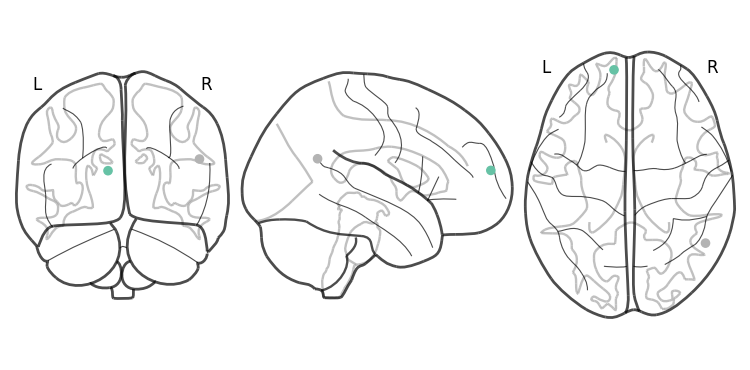

In [3]:
print("Number of ROI coordinates:", len(coords)) # make sure the right coords is using

# show 2 ROIs as example
roi_ids = [9, 50]   # change these

coords_sel = [coords[i] for i in roi_ids]

# Plot an "empty" connectome: no edges, just nodes on a brain outline
empty_adj = np.zeros((len(coords_sel), len(coords_sel)))

display = plotting.plot_connectome(
    empty_adj,
    coords_sel,
    edge_threshold="100%",   # hides all edges (since all zeros anyway)
    node_size=35,
    colorbar=False,
    # title="Example ROIs (CC200 atlas)"
)

display.savefig("empty_brain_rois.png", dpi=300)

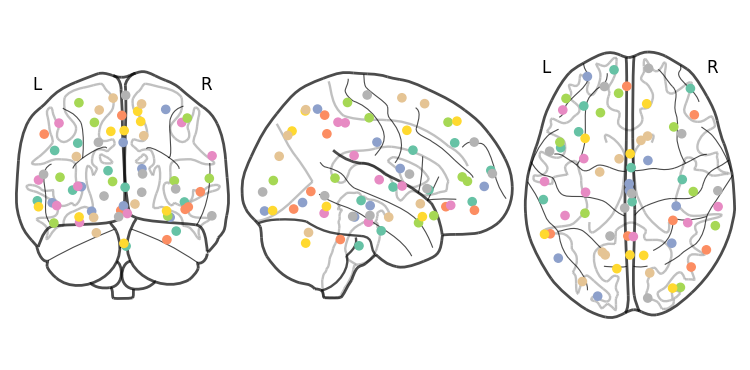

In [4]:
# example with many nodes
roi_ids = range(0, 200, 3) # take 1 every 3 nodes

coords_sel = [coords[i] for i in roi_ids]

# Plot an "empty" connectome: no edges, just nodes on a brain outline
empty_adj = np.zeros((len(coords_sel), len(coords_sel)))

display = plotting.plot_connectome(
    empty_adj,
    coords_sel,
    edge_threshold="100%",   # hides all edges (since all zeros anyway)
    node_size=35,
    colorbar=False,)

display.savefig("empty_brain_rois_with_60_ROIs.png", dpi=300)

### rs-fMRI data

In [5]:
# Map data files for subject ID, diagnosis, and collection site
# All these information are available as file name of the .1D files
# so parsing the file name to extract the information

RANDOM_SEED = 42 
np.random.seed(RANDOM_SEED) # ensure reproducibility

DATA_DIR = "data" # inside "data" folder there are subfolders "ASD" and "CONTROL"
roi_files = glob.glob(os.path.join(DATA_DIR, "**", "*rois_cc200*.1D"), recursive=True) # get the paths all .1D files
print(f"Found {len(roi_files)} .1D files for both ASD and control participants.")

records = []
for f in roi_files: # go through all paths
    basename = os.path.basename(f)  # extract the file name: example - "MaxMun_d_0051360_rois_cc200.1D"
    folder = os.path.basename(os.path.dirname(f))  # "ASD" or "CONTROL"
    parts = basename.split("_")      # split filename by "_" to get site and subject ID
    site = "_".join(parts[:-3])     # join everything except last three parts
    subject_id = parts[-3]          # the subject ID (like 0051360)
    # append all info as dict to record
    records.append({  
        "subject_id": subject_id,
        "diagnosis": folder,  # ASD/Control label comes from folder name
        "site": site,
        "file_path": f})

pheno_simple = pd.DataFrame(records)
# pheno_simple.to_csv("pheno_simple.csv", index = False)
# print("pheno_simple successfully saved to output.csv")
pheno_simple.head(2)

Found 679 .1D files for both ASD and control participants.


,subject_id,diagnosis,site,file_path
0,0051457,ASD,Caltech,data\ASD\Caltech_0051457_rois_cc200.1D
1,0051459,ASD,Caltech,data\ASD\Caltech_0051459_rois_cc200.1D


The MRI data covers 200 ROIs, with signals collected for 146 time points.


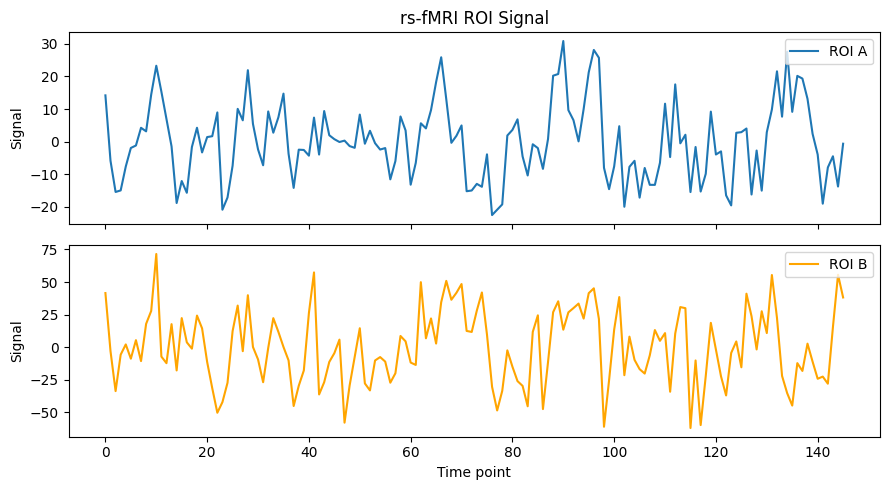

In [6]:
# MRI data: X - time series matrix
# each row is a time point that MRI collect signals (called time series)
# each colume is a region of brain (called region of interest - ROI)
ts_example = np.loadtxt(pheno_simple.iloc[0]["file_path"]) # check the first data point as an example
print(f"The MRI data covers {ts_example.shape[1]} ROIs, with signals collected for {ts_example.shape[0]} time points.")

# show the time series examples
ts = ts_example
roi_a, roi_b = 0, 50
t = np.arange(ts.shape[0])

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(9, 5), sharex=True)

# example signal plot
# Top plot (ROI A)
# axes[0].plot(t, ts[:, roi_a], label=f"ROI {roi_a+1}")
axes[0].plot(t, ts[:, roi_a], label=f"ROI A")
axes[0].set_title("rs-fMRI ROI Signal")
axes[0].set_ylabel("Signal")
axes[0].legend(loc="upper right")

# Bottom plot (ROI B) - orange
axes[1].plot(t, ts[:, roi_b], color="orange", label=f"ROI B")
axes[1].set_xlabel("Time point")
axes[1].set_ylabel("Signal")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [7]:
# Iterate all files to import MRI data, structure the dataset for analysis:
# X time series matrix: data used for prediction, features
# y (ASD/control label): what needed to be predicted
# group (collection site)

# prepare for iteration
# empty lists to store features/labels/groups during iteration
R = ts_example.shape[1]         # number of ROIs 
X_list = []      # upper-triangle vectorized values - holds each subject’s connectivity features
y_list = []      # labels for each subject, either 1=ASD or 0=control
groups = []      # SITE_ID per subject
included_subjects = []  # record of which subjects made it in

# initiate matrix to store accumulated sum; counts are also recorded
# advantage to do this is: no need to store all matrices for each subject and then calculate average
# average can be calculated later use accumulated sum matrix divided by counts
sumZ_asd = np.zeros((R, R), dtype=np.float64) # cumsum for ASD
count_asd = 0 # count for ASD
sumZ_tdc = np.zeros((R, R), dtype=np.float64) # cumsum for control
count_tdc = 0 # count for control
n_skipped_missing = 0

rows = pheno_simple.to_dict('records') # conver the df to dict so it is easier to iterate
print(rows[0])

# start iteration
start_time = time.time()
for row in rows:  # going through each subject
    fid = str(row["subject_id"]).strip()
    dx = row["diagnosis"]
    site = row["site"]
    path = row["file_path"]
    
    # map diagnosis into labels
    if dx == 'ASD':
        label = 1
    elif dx == 'CONTROL':
        label = 0
    else:
        continue # skip unknown dx codes

    # ROI time series
    try:
        ts = np.loadtxt(path)  # shape usually (T, R) - (146, 200) according to the first data point
    except Exception as e:
        print("Failed loading", path, e)
        continue
    T, Rcurr = ts.shape

    # Compute correlation matrix, aka brain functional connectivity
    with warnings.catch_warnings(): 
        warnings.simplefilter("ignore", category=RuntimeWarning) # mute division by zero warning and proceed, some σ = 0 cause the warning
        C = np.corrcoef(ts.T)               # calculate R x R Correlation across ROIs: p_ij = COV(i, j)/(σ_i * σ_j)
    
    C = np.nan_to_num(C, nan=1e-10)         # replace NaNs with 0 correlation
    
    # A correlation coefficient must be between -1 and 1. But due to numeric rounding 1 and -1 may present
    # which cause issues with np.arctanh() as it goes to infinity at ±1
    # so we clip a small eps to avoid 1 and -1 in the matrix
    eps = 1e-7
    C = np.clip(C, -1 + eps, 1 - eps)  # avoid +/-1

    # Fisher z transform
    # why Fisher z needed: 
    # Raw correlations r are not normally distributed, especially near -1 or 1 
    # “squished” into [-1, 1], so values near ±1 behave weirdly.
    # Fisher z-transform makes correlation values more Gaussian-like and stabilizes variance
    # “unsquishes” the scale so differences are more linear and comparable.
    #  example: r = 0.9 → z ≈ 1.472 or r = 0.99 → z ≈ 2.646
    # fisher z transform is helpful especially we are using correlations as features in models (later steps)
    Z = np.arctanh(C)  # Fisher z transform

    # turn 200×200 connectivity matrix into a 1D feature vector for machine learning
    iu = np.triu_indices(R, k=1) # returns the row and column indices for the upper triangle of matrix; k=1 skip the diagonal
    feat = Z[iu] # use the indices iu to pull out just those upper-triangle values from Z
    # feat becomes a 1D vector containing each unique ROI-to-ROI connection exactly once.

    # record the data to the lists initiated above
    X_list.append(feat.astype(np.float32))
    y_list.append(label)
    groups.append(site)
    included_subjects.append(fid)

    # accumulate group sum to calculate average later
    if label == 1:
        sumZ_asd += Z
        count_asd += 1
    else:
        sumZ_tdc += Z
        count_tdc += 1

print(f"Loaded features for {len(X_list)} subjects (skipped {n_skipped_missing} missing). "
      f"Time: {time.time()-start_time:.1f}s")

# X_list is a Python list where each item is one subject’s feature vector, e.g. feat of length 19,900.
# use np.vstack to stack them vertically into a 2-D matrix so that
# the matrix become (679, 19900), which is (n_subjects, n_features)
X = np.vstack(X_list).astype(np.float32)

# turn y_list and group into numpy arrays
y = np.array(y_list, dtype=np.int32)
groups = np.array(groups)

print("Feature matrix shape:", X.shape, "Labels:", np.bincount(y))

unique_groups = np.unique(groups)
print("Number of unique sites (groups):", len(unique_groups))

{'subject_id': '0051457', 'diagnosis': 'ASD', 'site': 'Caltech', 'file_path': 'data\\ASD\\Caltech_0051457_rois_cc200.1D'}
Loaded features for 679 subjects (skipped 0 missing). Time: 24.8s
Feature matrix shape: (679, 19900) Labels: [360 319]
Number of unique sites (groups): 24


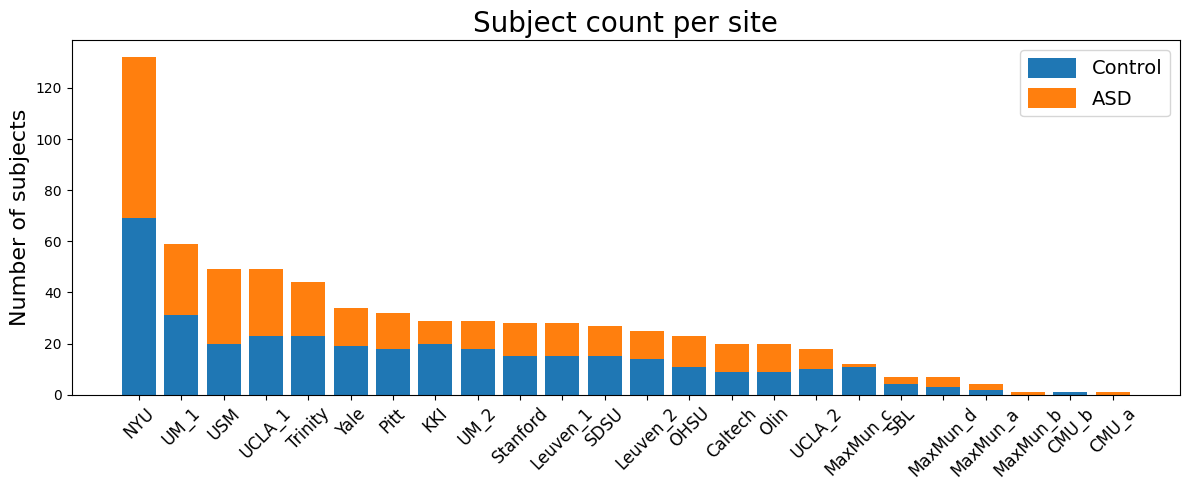

In [8]:
# plot subject count per site
df_counts = pd.DataFrame({"site": groups, "dx": y})

dx_map = {0: "Control", 1: "ASD"}
df_counts["dx_name"] = df_counts["dx"].map(dx_map)

site_dx = pd.crosstab(df_counts["site"], df_counts["dx_name"])

# Ensure both columns exist even if one class is missing in some sites
for col in ["Control", "ASD"]:
    if col not in site_dx.columns:
        site_dx[col] = 0
site_dx = site_dx[["Control", "ASD"]]

# Sort sites by total count (descending)
site_dx["Total"] = site_dx["Control"] + site_dx["ASD"]
site_dx = site_dx.sort_values("Total", ascending=False)
site_dx_no_total = site_dx.drop(columns=["Total"])

# Stacked bar plot
plt.figure(figsize=(12, 5))
plt.bar(site_dx_no_total.index.astype(str), site_dx_no_total["Control"], label="Control", color="tab:blue")
plt.bar(site_dx_no_total.index.astype(str), site_dx_no_total["ASD"],
        bottom=site_dx_no_total["Control"], label="ASD", color="tab:orange")

plt.xticks(rotation=45, fontsize = 12)
plt.ylabel("Number of subjects", fontsize=16)
plt.title("Subject count per site", fontsize=20)
plt.legend(fontsize=14, handlelength=2.5, handleheight=1.2)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "subject_count_per_site.png"), dpi=200)
plt.show()

### Heatmaps

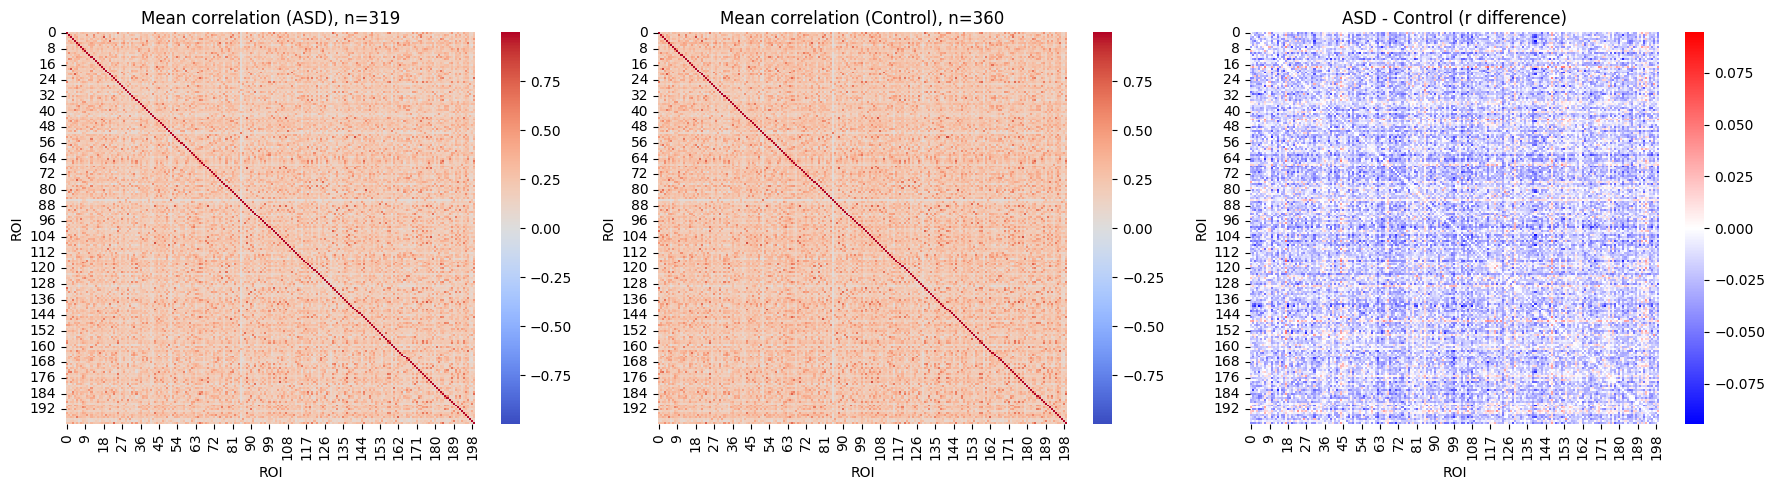

In [9]:
# Group heatmaps
# calculate ASD and control group mean, and the difference between the groups
meanZ_asd = sumZ_asd / count_asd
meanZ_tdc = sumZ_tdc / count_tdc

# recap the previous process happened above:
# start with correlations: C (values in [-1, 1])
# perform Fisher-transform them: Z = arctanh(C), which make values more “normal” and better for averaging/statistics.
# Take the average of each group

# Now inverse the Z back to R (inverse fisher Z-transform)
# why - Averaging raw correlations directly can be biased because correlations are “squished” near ±1 and not symmetric.
# Fisher z makes the distribution closer to normal and stabilizes variance, so the mean is more statistically meaningful.
# now convert back to correlation - because it is easier to explain correlations
# therefore, compute averages in Fisher z space for correct statistics, 
# then convert back to correlation space for readable plots and interpretation.

# inverse the fisher Z-transform and go back to correlation
# then calculate group difference
meanR_asd = np.tanh(meanZ_asd) # within -1 to 1
meanR_tdc = np.tanh(meanZ_tdc) # within -1 to 1
diffR = meanR_asd - meanR_tdc # group difference

# plot correlation heatmap
plt.figure(figsize=(18, 5))
vmax = max(np.abs(meanR_asd).max(), np.abs(meanR_tdc).max())

# ASD
plt.subplot(1,3,1)
sns.heatmap(meanR_asd, cmap="coolwarm", center=0, cbar=True, vmax=vmax, vmin=-vmax)
plt.title(f"Mean correlation (ASD), n={count_asd}")
plt.xlabel("ROI"); plt.ylabel("ROI")

# Control
plt.subplot(1,3,2)
sns.heatmap(meanR_tdc, cmap="coolwarm", center=0, cbar=True, vmax=vmax, vmin=-vmax)
plt.title(f"Mean correlation (Control), n={count_tdc}")
plt.xlabel("ROI"); plt.ylabel("ROI")

# Group difference
plt.subplot(1,3,3)
maxdiff = np.abs(diffR).max()
sns.heatmap(diffR, cmap="bwr", center=0, cbar=True, vmax=maxdiff, vmin=-maxdiff)
plt.title("ASD - Control (r difference)")
plt.xlabel("ROI"); plt.ylabel("ROI")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "mean_connectivity_heatmaps.png"), dpi=200)
# print("Saved heatmaps to mean_connectivity_heatmaps.png")

### Site effect - Dimensional reduction

Explained variance (PC1+PC2): 27.08%


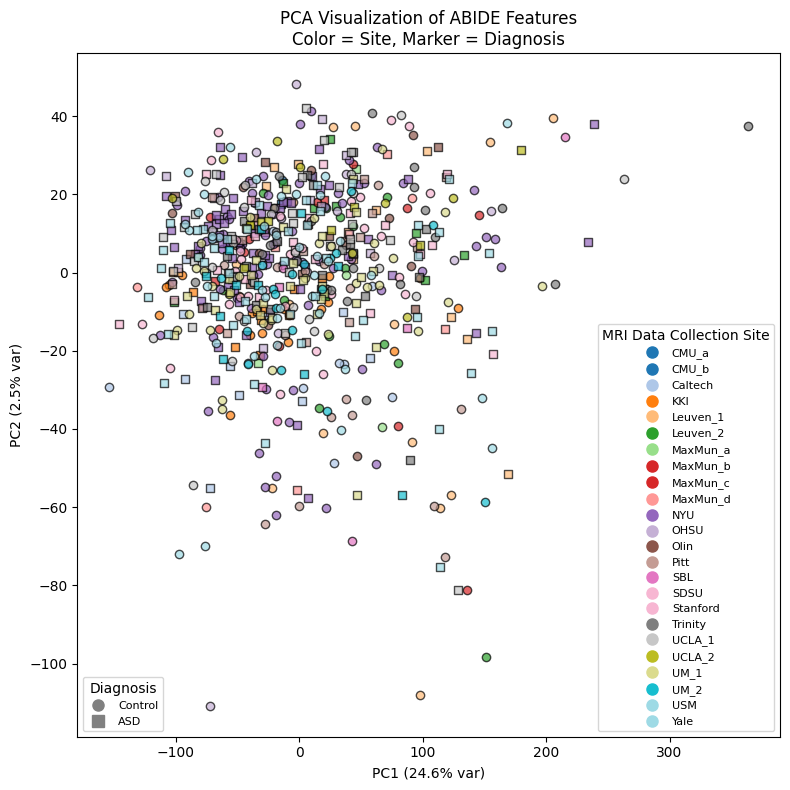

In [10]:
# PCA
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance (PC1+PC2): {pca.explained_variance_ratio_[:2].sum()*100:.2f}%")

# use color to label sites
sites = np.unique(groups)
colors = plt.get_cmap("tab20", len(sites)) 
# use marker to label diagnosis: Control = circle, ASD = square
markers = {0: 'o', 1: 's'} 
diagnosis_labels = {0: 'Control', 1: 'ASD'}

plt.figure(figsize=(8,8))

# plot individual points
for site_idx, site in enumerate(sites):
    for label in [0, 1]:
        mask = (groups == site) & (y == label)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=[colors(site_idx)],
                    marker=markers[label],
                    edgecolor="k",
                    alpha=0.7)

site_legend = [Line2D([0], [0], marker='o', color=colors(i), linestyle='', markersize=8, label=f"{site}")
               for i, site in enumerate(sites)]      

diagnosis_legend = [Line2D([0], [0], marker=markers[label], color='grey', linestyle='', markersize=8, label=diagnosis_labels[label])
                    for label in [0, 1]]

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("PCA Visualization of ABIDE Features\nColor = Site, Marker = Diagnosis")

# Add legends
first_legend = plt.legend(handles=site_legend, title="MRI Data Collection Site", loc="lower right", fontsize=8)
plt.gca().add_artist(first_legend)
plt.legend(handles=diagnosis_legend, title="Diagnosis", loc="lower left", fontsize=8)

plt.tight_layout()
plt.show()

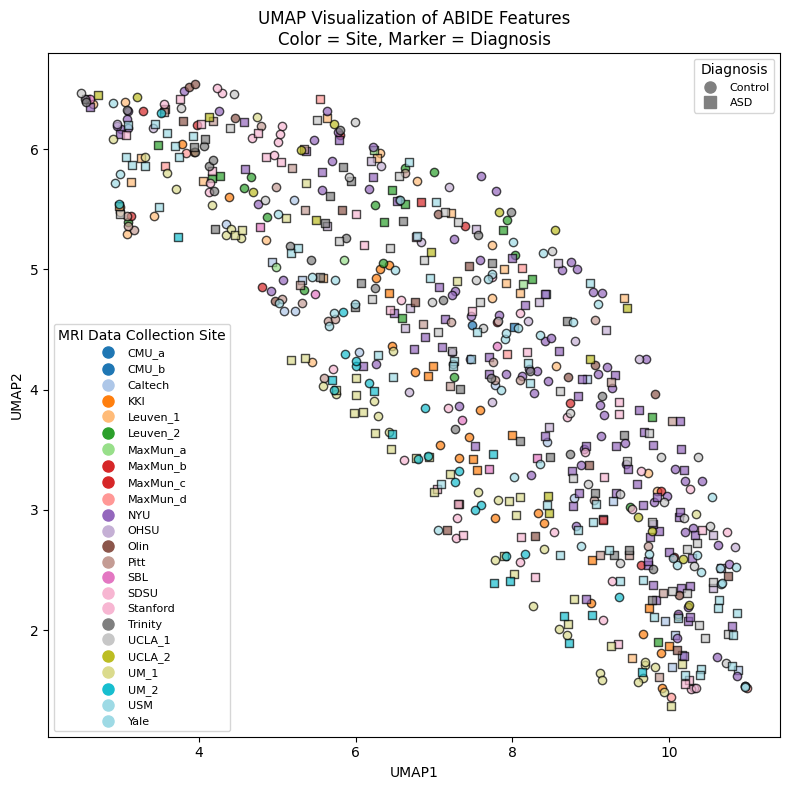

In [11]:
# UMAP
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

# Initialize UMAP
reducer = umap.UMAP(
    n_neighbors=15,   
    min_dist=0.1,    
    n_components=2,
    random_state=42, n_jobs=-1)
X_umap = reducer.fit_transform(X_scaled) # X_scaled defined in PCA section

plt.figure(figsize=(8,8))

# plot individual points
for site_idx, site in enumerate(sites):
    for label in [0, 1]:
        mask = (groups == site) & (y == label)
        plt.scatter(X_umap[mask, 0], X_umap[mask, 1],
                    c=[colors(site_idx)],
                    marker=markers[label],
                    edgecolor="k",
                    alpha=0.7)

# use color to label sites
site_legend = [Line2D([0], [0], marker='o', color=colors(i), linestyle='', markersize=8, label=f"{site}")
               for i, site in enumerate(sites)]  # sites and colors defined in PCA section  

# use marker to label diagnosis: Control = circle, ASD = square
diagnosis_legend = [Line2D([0], [0], marker=markers[label], color='grey', linestyle='', markersize=8, label=diagnosis_labels[label])
                    for label in [0, 1]] # markers and diagnosis_labels defined in PCA section

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP Visualization of ABIDE Features\nColor = Site, Marker = Diagnosis")

# Add legends
first_legend = plt.legend(handles=site_legend, title="MRI Data Collection Site", loc="lower left", fontsize=8)
plt.gca().add_artist(first_legend)
plt.legend(handles=diagnosis_legend, title="Diagnosis", loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

### Quantify site confound - LM approach

In [12]:
# Quantify the site confound

min_n = 10 # only use the site with subject count 10 or more

site_counts = pd.Series(groups).value_counts()
keep_sites = site_counts[site_counts >= min_n].index
mask = pd.Series(groups).isin(keep_sites).values

X_site = X[mask]
site_labels = np.array(groups)[mask]

print(f"Site-classifier dataset (min_n={min_n}):")
print("  Subjects kept:", X_site.shape[0], "/", X.shape[0])
print("  Sites kept:", len(np.unique(site_labels)), "/", len(np.unique(groups)))

# encode site labels -> 0..K-1
le_site = LabelEncoder()
y_site = le_site.fit_transform(site_labels)

# baseline accuracies for context
majority_acc = (pd.Series(site_labels).value_counts().max() / len(site_labels))
uniform_acc = 1.0 / len(le_site.classes_)
print("Baseline accuracy (majority site):", round(majority_acc, 3))
print("Baseline accuracy (uniform 1/K):  ", round(uniform_acc, 3))
print("K sites:", len(le_site.classes_))

Site-classifier dataset (min_n=10):
  Subjects kept: 658 / 679
  Sites kept: 18 / 24
Baseline accuracy (majority site): 0.201
Baseline accuracy (uniform 1/K):   0.056
K sites: 18


Majority baseline = 132/658 = 0.201 The largest site has 132 subjects out of 658. If we always predict the largest site for everyone, we’d be correct 20.1% of the time. This is a baseline that accounts for class imbalance.

Chance baseline = 1/18 = 0.056 If guessed a site uniformly at random among 18 sites, it be correct about 5.6% of the time.
This sets a true “no-skill” baseline. site classifier accuracy (0.831) is ~15× higher than random guessing, which is strong evidence that site fingerprints are real.

In [13]:
start_time = time.time()
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

site_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="saga",
        multi_class="multinomial",
        max_iter=5000,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42))

y_site_pred = cross_val_predict(site_clf, X_site, y_site, cv=cv, n_jobs=-1, method="predict")

acc_site = accuracy_score(y_site, y_site_pred)
balacc_site = balanced_accuracy_score(y_site, y_site_pred)
f1_macro = f1_score(y_site, y_site_pred, average="macro")
f1_weighted = f1_score(y_site, y_site_pred, average="weighted")

print("=== Site prediction from connectomes (CV) ===")
print(f"Accuracy:          {acc_site:.3f}")
print(f"Balanced Accuracy: {balacc_site:.3f}")
print(f"Macro-F1:          {f1_macro:.3f}   (best for uneven site sizes)")
print(f"Weighted-F1:       {f1_weighted:.3f}")

print(f"Time: {time.time()-start_time:.1f}s")

=== Site prediction from connectomes (CV) ===
Accuracy:          0.831
Balanced Accuracy: 0.767
Macro-F1:          0.780   (best for uneven site sizes)
Weighted-F1:       0.824
Time: 5083.4s


F1-score computed per site, then averaged equally across sites. Macro-Fi is the average of all F1-scores. Macro-F1 is a fairness-aware metric: it treats a small site and a large site equally. So 0.780 means the model performs strongly across sites overall, not just by doing well on the largest site.

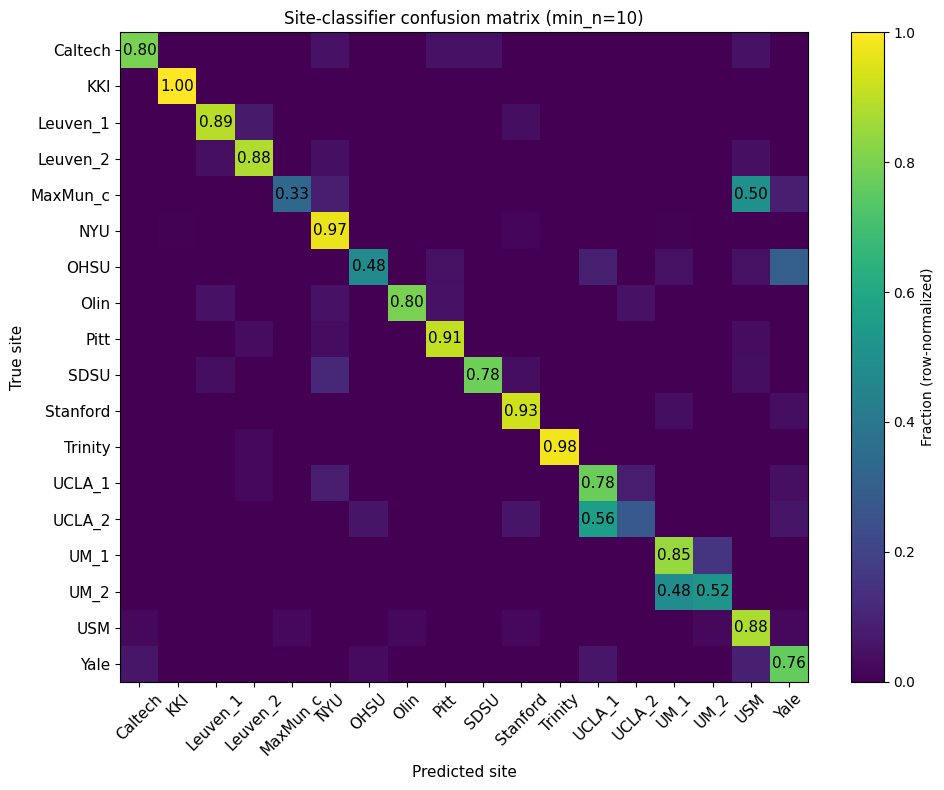

In [14]:
cm = confusion_matrix(y_site, y_site_pred, normalize="true")  # each row sums to 1
labels = le_site.classes_

plt.figure(figsize=(10,8))
plt.imshow(cm, aspect="auto")
plt.colorbar(label="Fraction (row-normalized)")
plt.xticks(range(len(labels)), labels, rotation=45, fontsize=11)
plt.yticks(range(len(labels)), labels, fontsize=11)
plt.xlabel("Predicted site", fontsize=11)
plt.ylabel("True site", fontsize=11)
plt.title(f"Site-classifier confusion matrix (min_n={min_n})")

thr = 0.32
fontsize = 11

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        if np.isnan(val) or val <= thr:
            continue
        # choose text color for readability
        text_color = "black" if val > thr else "white"
        plt.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=fontsize, color=text_color)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "site_classifier_CM.png"), dpi=200)
plt.show()

### Quantify site confound - Statistical approach (Variance explained in each edge by the factor)

In [15]:
Xf = X.astype(np.float64)
n, p = Xf.shape
overall_mean = Xf.mean(axis=0)

# Diagnosis eta^2 (2-group)
mask_asd = (y == 1)
mask_ctl = (y == 0)

n1 = mask_asd.sum()
n0 = mask_ctl.sum()

m1 = Xf[mask_asd].mean(axis=0)
m0 = Xf[mask_ctl].mean(axis=0)

ss_between_dx = n1*(m1 - overall_mean)**2 + n0*(m0 - overall_mean)**2
ss_total = ((Xf - overall_mean)**2).sum(axis=0) + 1e-12  # avoid /0

eta2_dx = ss_between_dx / ss_total

# Site eta^2 (multi-group)
site_series = pd.Series(groups)
site_levels = site_series.unique()

ss_between_site = np.zeros(p, dtype=np.float64)

for s in site_levels:
    idx = (site_series.values == s)
    ns = idx.sum()
    if ns == 0:
        continue
    ms = Xf[idx].mean(axis=0)
    ss_between_site += ns*(ms - overall_mean)**2

eta2_site = ss_between_site / ss_total

print("=== Variance explained (eta^2) summary across 19,900 edges ===")
print("Median eta^2 (diagnosis):", float(np.median(eta2_dx)))
print("Median eta^2 (site):     ", float(np.median(eta2_site)))
print("Percent edges where site eta^2 > dx eta^2:",
      float(np.mean(eta2_site > eta2_dx))*100, "%")

# ratios for “how much larger”
ratio = (eta2_site + 1e-12) / (eta2_dx + 1e-12)
print("Percent edges where site effect > 2× diagnosis effect:",
      float(np.mean(ratio > 2))*100, "%")
print("Percent edges where site effect > 5× diagnosis effect:",
      float(np.mean(ratio > 5))*100, "%")

=== Variance explained (eta^2) summary across 19,900 edges ===
Median eta^2 (diagnosis): 0.002713938090781534
Median eta^2 (site):      0.09154180915778692
Percent edges where site eta^2 > dx eta^2: 100.0 %
Percent edges where site effect > 2× diagnosis effect: 99.68844221105527 %
Percent edges where site effect > 5× diagnosis effect: 94.17085427135679 %


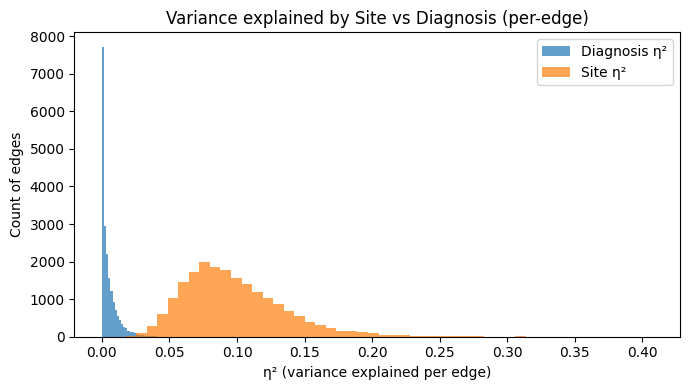

In [16]:
plt.figure(figsize=(7,4))
plt.hist(eta2_dx, bins=50, alpha=0.7, label="Diagnosis η²")
plt.hist(eta2_site, bins=50, alpha=0.7, label="Site η²")
plt.xlabel("η² (variance explained per edge)")
plt.ylabel("Count of edges")
plt.title("Variance explained by Site vs Diagnosis (per-edge)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "variance_explained_by_site_diagnosis.png"), dpi=200)
plt.show()

For each connectivity edge, η² (eta-squared) measure how much of the edge’s variability across subjects can be explained by a factor (site or diagnosis). η² is the fraction of variance in that edge explained by the factor. For example, η² = 0.10 means 10% of variability is explained by that factor. Median η²(site) = 0.0915 and Median η²(dx) = 0.0027; 100% edges: site > diagnosis; Because the median variance explained by site (0.0915) is larger than by diagnosis (0.0027), and site exceeds diagnosis for 100% of edges (and exceeds it by >5× for 94%), the connectome feature space is dominated by site/scanner effects, which is exactly why strict cross-site evaluation like LOSO is essential for fair ASD classification.

### Logistic Regression - Random 80/20 split

Random split (80/20) accuracy = 0.6103, AUC = 0.6756, AP = 0.6321
Confusion matrix:
 [[40 32]
 [21 43]]

Classification Report:
               precision    recall  f1-score   support

           0      0.656     0.556     0.602        72
           1      0.573     0.672     0.619        64

    accuracy                          0.610       136
   macro avg      0.615     0.614     0.610       136
weighted avg      0.617     0.610     0.610       136

{'accuracy': 0.6102941176470589, 'auc': 0.6755642361111112, 'avg_precision': 0.6320607309495738, 'sensitivity_recall_pos': 0.6718749999999896, 'specificity_recall_neg': 0.5555555555555479, 'n': 136}


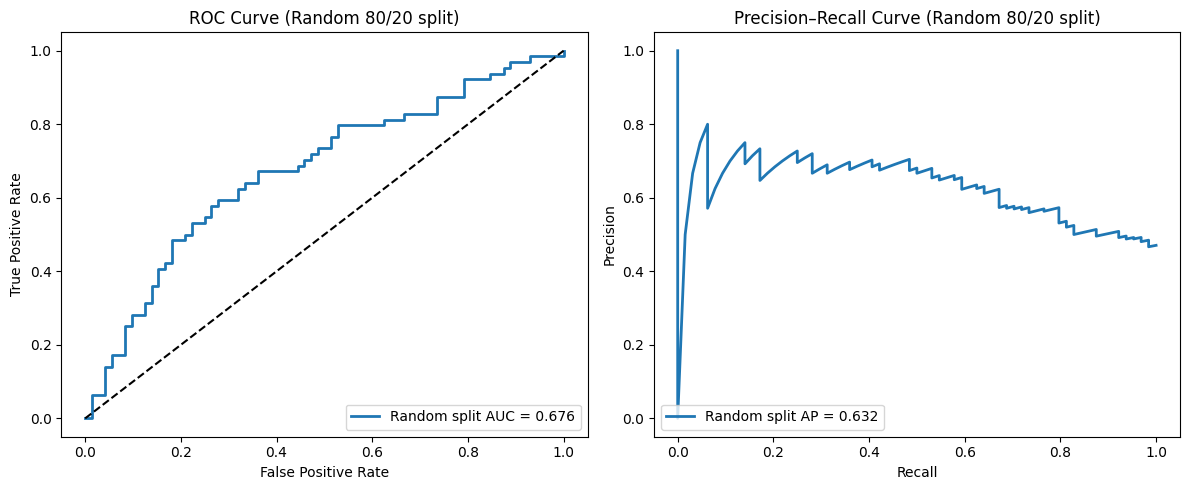

In [17]:
# Random Split baseline (naive) - for comparison with LOSO
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y)

rand_clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="liblinear",
        max_iter=2000,
        random_state=RANDOM_SEED))

rand_clf.fit(X_tr, y_tr)

yhat_rand = rand_clf.predict(X_te)
yprob_rand = rand_clf.predict_proba(X_te)[:, 1]

rand_acc = accuracy_score(y_te, yhat_rand)
rand_auc = roc_auc_score(y_te, yprob_rand)
rand_ap  = average_precision_score(y_te, yprob_rand)
cm_rand  = confusion_matrix(y_te, yhat_rand)

print(f"Random split (80/20) accuracy = {rand_acc:.4f}, AUC = {rand_auc:.4f}, AP = {rand_ap:.4f}")
print("Confusion matrix:\n", cm_rand)
print("\nClassification Report:\n", classification_report(y_te, yhat_rand, digits=3))

# Save metrics dict for random split
tn, fp, fn, tp = cm_rand.ravel()
random_single_metrics = {
    "accuracy": float(rand_acc),
    "auc": float(rand_auc),
    "avg_precision": float(rand_ap),
    "sensitivity_recall_pos": float(tp / (tp + fn + 1e-12)),
    "specificity_recall_neg": float(tn / (tn + fp + 1e-12)),
    "n": int(len(y_te)),}
print(random_single_metrics)

plt.figure(figsize = (12, 5))

# ROC curve
fpr_r, tpr_r, _ = roc_curve(y_te, yprob_rand)
plt.subplot(1,2,1)
plt.plot(fpr_r, tpr_r, lw=2, label=f"Random split AUC = {rand_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Random 80/20 split)")
plt.legend(loc="lower right")

# Precision-Recall curve
prec_r, rec_r, _ = precision_recall_curve(y_te, yprob_rand)
plt.subplot(1,2,2)
plt.plot(rec_r, prec_r, lw=2, label=f"Random split AP = {rand_ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Random 80/20 split)")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [18]:
# Repeated random splits to estimate variability 
start_time = time.time()

sss = StratifiedShuffleSplit(n_splits=100, test_size=0.20, random_state=RANDOM_SEED)

accs, aucs, aps = [], [], []
for train_idx, test_idx in sss.split(X, y):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_SEED))
    clf.fit(X_tr, y_tr)
    yhat = clf.predict(X_te)
    yprob = clf.predict_proba(X_te)[:, 1]

    accs.append(accuracy_score(y_te, yhat))
    aucs.append(roc_auc_score(y_te, yprob))
    aps.append(average_precision_score(y_te, yprob))

random_repeat_metrics = {
    "accuracy_mean": float(np.mean(accs)),
    "accuracy_std": float(np.std(accs)),
    "auc_mean": float(np.mean(aucs)),
    "auc_std": float(np.std(aucs)),
    "avg_precision_mean": float(np.mean(aps)),
    "avg_precision_std": float(np.std(aps)),
    "n_splits": int(len(accs)),}
print(random_repeat_metrics)

print(f"Time: {time.time()-start_time:.1f}s")

{'accuracy_mean': 0.685220588235294, 'accuracy_std': 0.03464000165318807, 'auc_mean': 0.7432096354166667, 'auc_std': 0.0374064378924012, 'avg_precision_mean': 0.7112659243154238, 'avg_precision_std': 0.047955454228310684, 'n_splits': 100}
Time: 544.8s


### LOSO

In [19]:
# Logistic Regression with leave one site out cross validation (CV)

# there are 24 unique sites, so CV is 24 fold
# define a function run_fold() to run/reuse for all 24 folds
# run_fold() runs one cross-validation fold (one train/test split) for
# logistic regression pipeline and returns the fold’s results
def run_fold(train_idx, test_idx):
    # split training and test set for a fold; splitting is based on sites
    X_tr, X_te = X[train_idx], X[test_idx] 
    y_tr, y_te = y[train_idx], y[test_idx]
    # make a 2-step pipeline: 
    # Step 1: StandardScaler(): standardizes each feature (mean 0, std 1) using the training set
    # standardization is important because connectivity edges have different ranges
    # Step 2: LogisticRegression(): trains a classifier to predict ASD vs control.
    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver='liblinear',
            max_iter=2000,
            random_state=RANDOM_SEED))
    clf.fit(X_tr, y_tr) # training step
    yhat = clf.predict(X_te)      # predicting the test set (the left out site)
    yhat_proba = clf.predict_proba(X_te)[:,1]     # calculate probability of class 1 (ASD)
    acc = accuracy_score(y_te, yhat)     # calculate accuracy
    
    # Extract the learned feature weights (coefficients)
    # this shows the importance of each connectivity/feature/edge
    coefs = clf.named_steps['logisticregression'].coef_[0]
    
    return acc, y_te.tolist(), yhat.tolist(), yhat_proba.tolist(), coefs.tolist()

def run_fold_X(X_in, y_in, train_idx, test_idx, random_seed=0):
    X_tr, X_te = X_in[train_idx], X_in[test_idx]
    y_tr, y_te = y_in[train_idx], y_in[test_idx]

    clf = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            random_state=random_seed
        )
    )

    clf.fit(X_tr, y_tr)
    yhat = clf.predict(X_te)
    yhat_proba = clf.predict_proba(X_te)[:, 1]
    acc = accuracy_score(y_te, yhat)

    coefs = clf.named_steps["logisticregression"].coef_[0]  # length = n_features_used
    return acc, y_te.tolist(), yhat.tolist(), yhat_proba.tolist(), coefs.tolist()

def run_loso_eval(X_in, y_in, groups_in, random_seed=0):
    logo = LeaveOneGroupOut()

    fold_acc = []
    y_true_all, y_pred_all, y_proba_all = [], [], []
    coefs_all = []

    for train_idx, test_idx in logo.split(X_in, y_in, groups_in):
        acc, y_te, yhat, yhat_proba, coefs = run_fold_X(
            X_in, y_in, train_idx, test_idx, random_seed=random_seed
        )
        fold_acc.append(acc)
        y_true_all.extend(y_te)
        y_pred_all.extend(yhat)
        y_proba_all.extend(yhat_proba)
        coefs_all.append(coefs)

    fold_acc = np.array(fold_acc, dtype=float)
    obs_acc = float(fold_acc.mean())
    obs_std = float(fold_acc.std())
    obs_auc = float(roc_auc_score(y_true_all, y_proba_all))

    return {
        "mean_fold_acc": obs_acc,
        "std_fold_acc": obs_std,
        "agg_auc": obs_auc,
        "fold_acc": fold_acc,
        "y_true": np.array(y_true_all),
        "y_pred": np.array(y_pred_all),
        "y_proba": np.array(y_proba_all),
        "mean_coefs": np.mean(np.array(coefs_all), axis=0)  # feature-length depends on mask
    }

In [20]:
# Run LOSO
logo = LeaveOneGroupOut() 

start_time = time.time()

# run the run_fold() function once for each LOSO split
# use the Parallel() function so that the codes run in parallel (using all CPU cores) to speed things up
# purpose to use Parallel and delayed is to speed up the cross validation/model training process
results = Parallel(n_jobs=-1)(  # n_jobs=-1 means use all available CPU cores (maximum parallelism)
    # delayed: Don’t run run_fold immediately—package it up as a task to run later with tasks: run_fold(fold1_train, fold1_test)
    delayed(run_fold)(train_idx, test_idx)
    # for loop to go through every fold generated by LOSO
    for train_idx, test_idx in logo.split(X, y, groups)) # logo.split(X, y, groups) split train/test based on group/site

# Aggregate metrics
fold_accuracies = [r[0] for r in results]
y_true_all = [y for r in results for y in r[1]]
y_pred_all = [y for r in results for y in r[2]]
y_pred_proba_all = [p for r in results for p in r[3]]

# Collect coefficients and average across folds
coefs_all = np.array([r[4] for r in results])  # shape = (n_folds, n_features)
mean_coefs = coefs_all.mean(axis=0)

obs_acc = np.mean(fold_accuracies)
obs_auc = roc_auc_score(y_true_all, y_pred_proba_all)
print(f"LOSO mean accuracy = {obs_acc:.4f} (std {np.std(fold_accuracies):.4f}), aggregated AUC = {obs_auc:.4f}")
print(f"Run time: {time.time()-start_time:.1f}s")

# Per-class Precision, Recall, F1
print("Classification Report:\n")
print(classification_report(y_true_all, y_pred_all, digits=3))

# per-site accuracy
site_names = []
site_test_n = []

# same order for site and number of objects
for _, test_idx in logo.split(X, y, groups):
    site_names.append(groups[test_idx][0])     # held-out site name
    site_test_n.append(len(test_idx))          # number of subjects in that test site

site_acc_df = pd.DataFrame({
    "Site": site_names,
    "N_test": site_test_n,
    "Accuracy": fold_accuracies
})

# Sort for a cleaner bar chart (low → high)
# site_acc_df = site_acc_df.sort_values("Accuracy").reset_index(drop=True)

# Optional: make labels include sample size
site_acc_df["Site_label"] = site_acc_df.apply(
    lambda r: f"{r['Site']} (n={int(r['N_test'])})", axis=1
)

site_acc_df.head(24)

LOSO mean accuracy = 0.7001 (std 0.1505), aggregated AUC = 0.7379
Run time: 70.9s
Classification Report:

              precision    recall  f1-score   support

           0      0.697     0.683     0.690       360
           1      0.650     0.665     0.657       319

    accuracy                          0.675       679
   macro avg      0.674     0.674     0.674       679
weighted avg      0.675     0.675     0.675       679



,Site,N_test,Accuracy,Site_label
0,CMU_a,1,1.000000,CMU_a (n=1)
1,CMU_b,1,1.000000,CMU_b (n=1)
2,Caltech,20,0.550000,Caltech (n=20)
3,KKI,29,0.551724,KKI (n=29)
4,Leuven_1,28,0.714286,Leuven_1 (n=28)
5,Leuven_2,25,0.600000,Leuven_2 (n=25)
6,MaxMun_a,4,0.500000,MaxMun_a (n=4)
7,MaxMun_b,1,1.000000,MaxMun_b (n=1)
8,MaxMun_c,12,0.416667,MaxMun_c (n=12)
9,MaxMun_d,7,0.571429,MaxMun_d (n=7)


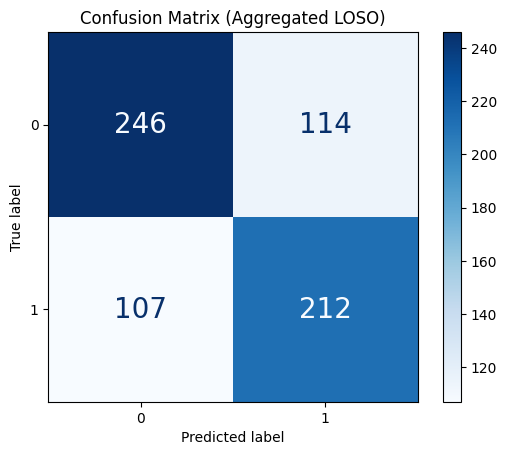

In [21]:
# plot confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, text_kw={"fontsize": 20})
plt.title("Confusion Matrix (Aggregated LOSO)")
plt.savefig(os.path.join(DATA_DIR, "CM_Aggregated_LOSO"), dpi=200)
plt.show()

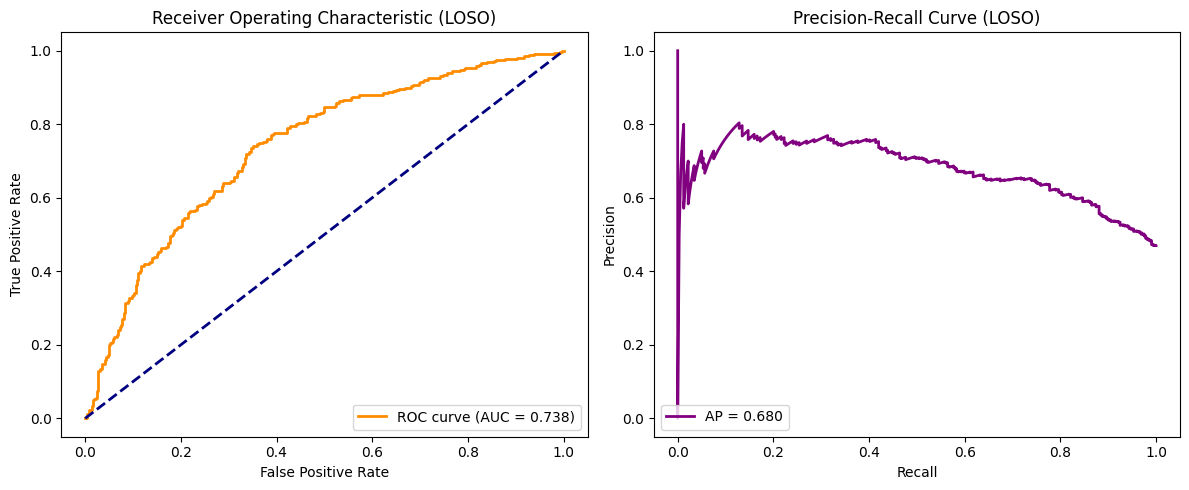

In [22]:
# ROC Curve and Precision-Recall Curve
plt.figure(figsize = (12, 5))

fpr, tpr, _ = roc_curve(y_true_all, y_pred_proba_all)
roc_auc = auc(fpr, tpr)
plt.subplot(1,2,1)
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (LOSO)")
plt.legend(loc="lower right")

precision, recall, _ = precision_recall_curve(y_true_all, y_pred_proba_all)
avg_prec = average_precision_score(y_true_all, y_pred_proba_all)
plt.subplot(1,2,2)
plt.plot(recall, precision, color="purple", lw=2, label=f"AP = {avg_prec:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LOSO)")
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [23]:
# Save LOSO summary metrics for later comparison
tn, fp, fn, tp = cm.ravel()
loso_metrics = {
    "accuracy_mean": float(obs_acc),
    "accuracy_std": float(np.std(fold_accuracies)),
    "auc": float(obs_auc),
    "avg_precision": float(avg_prec),
    "sensitivity_recall_pos": float(tp / (tp + fn + 1e-12)),
    "specificity_recall_neg": float(tn / (tn + fp + 1e-12)),
    "n": int(len(y_true_all)),}

comparison = pd.DataFrame([
    {   "Protocol": "LOSO (Leave-One-Site-Out)",
        "Accuracy": loso_metrics["accuracy_mean"],
        "Acc Std": loso_metrics["accuracy_std"],
        "AUC": loso_metrics["auc"],
        "Avg Precision": loso_metrics["avg_precision"],
        "Sensitivity (ASD recall)": loso_metrics["sensitivity_recall_pos"],
        "Specificity (Control recall)": loso_metrics["specificity_recall_neg"],
        "N": loso_metrics["n"],},
    {   "Protocol": "Random split (single 80/20)",
        "Accuracy": random_single_metrics["accuracy"],
        "Acc Std": np.nan,
        "AUC": random_single_metrics["auc"],
        "Avg Precision": random_single_metrics["avg_precision"],
        "Sensitivity (ASD recall)": random_single_metrics["sensitivity_recall_pos"],
        "Specificity (Control recall)": random_single_metrics["specificity_recall_neg"],
        "N": random_single_metrics["n"],},
    {   "Protocol": "Random split (50 repeats, mean±std)",
        "Accuracy": random_repeat_metrics["accuracy_mean"],
        "Acc Std": random_repeat_metrics["accuracy_std"],
        "AUC": random_repeat_metrics["auc_mean"],
        "Avg Precision": random_repeat_metrics["avg_precision_mean"],
        "Sensitivity (ASD recall)": np.nan,
        "Specificity (Control recall)": np.nan,
        "N": np.nan,}])

comparison

,Protocol,Accuracy,Acc Std,AUC,Avg Precision,Sensitivity (ASD recall),Specificity (Control recall),N
0,LOSO (Leave-One-Site-Out),0.700129,0.150526,0.737914,0.679839,0.664577,0.683333,679.0
1,Random split (single 80/20),0.610294,NaN,0.675564,0.632061,0.671875,0.555556,136.0
2,"Random split (50 repeats, mean±std)",0.685221,0.034640,0.743210,0.711266,NaN,NaN,NaN


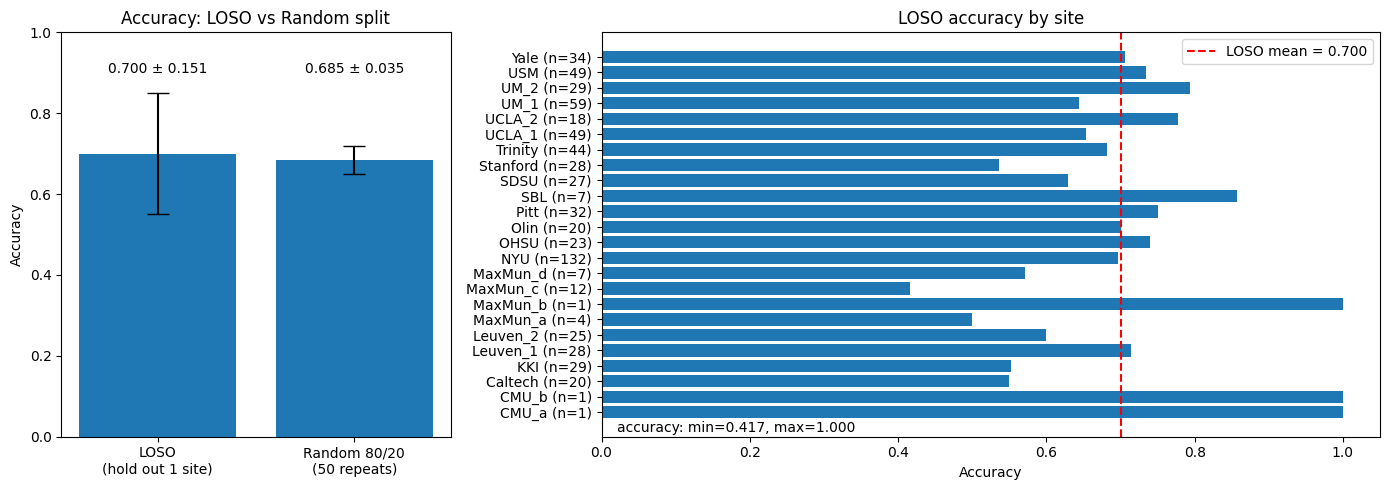

In [24]:
# plot 80/20 vs LOSO comparison + per-site variation
loso_acc_mean = loso_metrics["accuracy_mean"]
loso_acc_std  = loso_metrics["accuracy_std"]

rand_acc_mean = random_repeat_metrics["accuracy_mean"]
rand_acc_std  = random_repeat_metrics["accuracy_std"]

labels = ["LOSO\n(hold out 1 site)", "Random 80/20\n(50 repeats)"]
means  = [loso_acc_mean, rand_acc_mean]
errs   = [loso_acc_std,  rand_acc_std]

x = np.arange(len(labels))

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5),
    gridspec_kw={"width_ratios": [1, 2.0]}
)

# -LOSO vs Random 80/20
ax1.bar(x, means, yerr=errs, capsize=8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0.0, 1.0)
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy: LOSO vs Random split")

for i, (m, e) in enumerate(zip(means, errs)):
    ax1.text(i, 0.9, f"{m:.3f} ± {e:.3f}", ha="center")

# LOSO accuracy by site
ax2.barh(site_acc_df["Site_label"], site_acc_df["Accuracy"])
ax2.axvline(loso_acc_mean, linestyle="--", color='red', label=f"LOSO mean = {loso_acc_mean:.3f}")
ax2.set_xlim(0.0, 1.05)
ax2.set_xlabel("Accuracy")
ax2.set_title("LOSO accuracy by site")
ax2.text(0.02, 0.011,
         f"accuracy: min={site_acc_df['Accuracy'].min():.3f}, max={site_acc_df['Accuracy'].max():.3f}",
         transform=ax2.transAxes)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "barchart LOSO accuracy by site.png"), dpi=200)
plt.show()

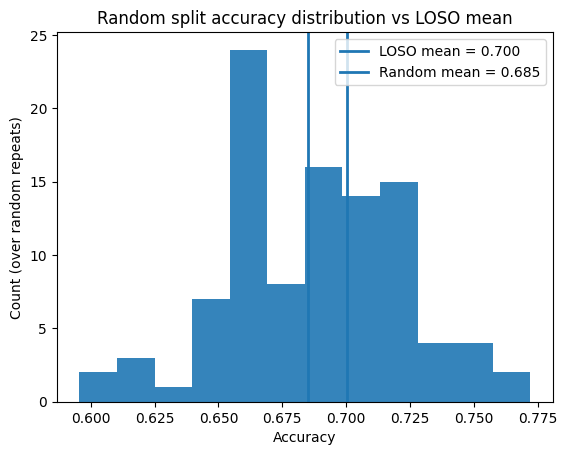

In [25]:
plt.figure()
plt.hist(accs, bins=12, alpha=0.9)
plt.axvline(loso_metrics["accuracy_mean"], linewidth=2,
            label=f"LOSO mean = {loso_metrics['accuracy_mean']:.3f}")
plt.axvline(np.mean(accs), linewidth=2,
            label=f"Random mean = {np.mean(accs):.3f}")

plt.xlabel("Accuracy")
plt.ylabel("Count (over random repeats)")
plt.title("Random split accuracy distribution vs LOSO mean")
plt.legend()
plt.show()

### LOSO Clinical Metrics

In [26]:
# Clinical metrics aggregated across LOSO predictions
acc = accuracy_score(y_true_all, y_pred_all)
bal_acc = balanced_accuracy_score(y_true_all, y_pred_all)

# confusion matrix: [[tn, fp],[fn, tp]]
tn, fp, fn, tp = confusion_matrix(y_true_all, y_pred_all).ravel()

sensitivity = tp / (tp + fn + 1e-12)   # recall for ASD (positive class)
specificity = tn / (tn + fp + 1e-12)   # recall for Control (negative class)

precision_pos = precision_score(y_true_all, y_pred_all, zero_division=0)
f1_pos = f1_score(y_true_all, y_pred_all, zero_division=0)

auc_agg = roc_auc_score(y_true_all, y_pred_proba_all)
brier = brier_score_loss(y_true_all, y_pred_proba_all)

print("=== Aggregated LOSO metrics ===")
print(f"Accuracy:           {acc:.3f}")
print(f"Balanced Accuracy:  {bal_acc:.3f}")
print(f"ROC-AUC:            {auc_agg:.3f}")
print(f"Sensitivity (TPR):  {sensitivity:.3f}")
print(f"Specificity (TNR):  {specificity:.3f}")
print(f"Precision (ASD):    {precision_pos:.3f}")
print(f"F1 (ASD):           {f1_pos:.3f}")
print(f"Brier score:        {brier:.3f}  (lower is better)")

=== Aggregated LOSO metrics ===
Accuracy:           0.675
Balanced Accuracy:  0.674
ROC-AUC:            0.738
Sensitivity (TPR):  0.665
Specificity (TNR):  0.683
Precision (ASD):    0.650
F1 (ASD):           0.657
Brier score:        0.259  (lower is better)


In [27]:
def bootstrap_ci(y_true, y_pred, y_prob, metric_fn, n_boot=2000, seed=42):
    """
    Bootstrap CI over subjects (aggregated LOSO predictions).
    metric_fn signature: metric_fn(y_true, y_pred, y_prob) -> float
    Returns: (mean, low, high)
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)  # resample subjects with replacement
        yt = y_true[idx]
        yp = y_pred[idx]
        ypr = y_prob[idx]

        # some metrics (AUC) fail if a bootstrap sample has only one class
        try:
            v = metric_fn(yt, yp, ypr)
            if np.isfinite(v):
                vals.append(v)
        except Exception:
            continue

    vals = np.asarray(vals)
    mean = float(np.mean(vals))
    low, high = np.percentile(vals, [2.5, 97.5])
    return mean, float(low), float(high)

def m_acc(yt, yp, ypr): return accuracy_score(yt, yp)
def m_balacc(yt, yp, ypr): return balanced_accuracy_score(yt, yp)
def m_auc(yt, yp, ypr): return roc_auc_score(yt, ypr)
def m_brier(yt, yp, ypr): return brier_score_loss(yt, ypr)

def m_sens(yt, yp, ypr):
    tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
    return tp / (tp + fn + 1e-12)

def m_spec(yt, yp, ypr):
    tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
    return tn / (tn + fp + 1e-12)

ci_acc    = bootstrap_ci(y_true_all, y_pred_all, y_pred_proba_all, m_acc)
ci_balacc = bootstrap_ci(y_true_all, y_pred_all, y_pred_proba_all, m_balacc)
ci_auc    = bootstrap_ci(y_true_all, y_pred_all, y_pred_proba_all, m_auc)
ci_sens   = bootstrap_ci(y_true_all, y_pred_all, y_pred_proba_all, m_sens)
ci_spec   = bootstrap_ci(y_true_all, y_pred_all, y_pred_proba_all, m_spec)
ci_brier  = bootstrap_ci(y_true_all, y_pred_all, y_pred_proba_all, m_brier)

print("=== 95% Bootstrap CIs (aggregated LOSO predictions) ===")
print(f"Accuracy:          {ci_acc[0]:.3f}  [{ci_acc[1]:.3f}, {ci_acc[2]:.3f}]")
print(f"Balanced Accuracy: {ci_balacc[0]:.3f}  [{ci_balacc[1]:.3f}, {ci_balacc[2]:.3f}]")
print(f"ROC-AUC:           {ci_auc[0]:.3f}  [{ci_auc[1]:.3f}, {ci_auc[2]:.3f}]")
print(f"Sensitivity:       {ci_sens[0]:.3f}  [{ci_sens[1]:.3f}, {ci_sens[2]:.3f}]")
print(f"Specificity:       {ci_spec[0]:.3f}  [{ci_spec[1]:.3f}, {ci_spec[2]:.3f}]")
print(f"Brier score:       {ci_brier[0]:.3f}  [{ci_brier[1]:.3f}, {ci_brier[2]:.3f}]")

=== 95% Bootstrap CIs (aggregated LOSO predictions) ===
Accuracy:          0.674  [0.638, 0.710]
Balanced Accuracy: 0.673  [0.638, 0.709]
ROC-AUC:           0.737  [0.699, 0.774]
Sensitivity:       0.664  [0.615, 0.717]
Specificity:       0.682  [0.632, 0.731]
Brier score:       0.259  [0.232, 0.287]


In [28]:
p = np.mean(y_true_all)                 # ASD prevalence
brier_ref = p*(1-p)                    # Brier for always predicting prevalence
brier_skill = 1 - (brier / brier_ref)  # >0 means better than baseline
print("Prevalence:", p, "Baseline Brier:", brier_ref, "Brier Skill:", brier_skill)

Prevalence: 0.4698085419734904 Baseline Brier: 0.2490884758622335 Brier Skill: -0.039283644746988644


In [29]:
y_true = np.asarray(y_true_all).astype(int)
y_prob = np.asarray(y_pred_proba_all).astype(float)

thresholds = np.linspace(0, 1, 201)  # 0.005 step
rows = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_t).ravel()

    sens = tp / (tp + fn + 1e-12)   # TPR
    spec = tn / (tn + fp + 1e-12)   # TNR
    prec = tp / (tp + fp + 1e-12)
    f1 = 2 * prec * sens / (prec + sens + 1e-12)
    youdenJ = sens + spec - 1

    rows.append([t, sens, spec, prec, f1, youdenJ, tp, fp, tn, fn])

thr_df = pd.DataFrame(rows, columns=[
    "threshold","sensitivity","specificity","precision","f1","youdenJ",
    "tp","fp","tn","fn"
])

# --- recommended operating points ---
# 1) Default
t_default = 0.50
default_row = thr_df.iloc[(thr_df["threshold"] - t_default).abs().argsort()[:1]]
# default_row = thr_df.loc[(thr_df["threshold"] - t_default).abs().idxmin()]

# 2) Youden's J optimum (balanced sens/spec)
bestJ_row = thr_df.loc[thr_df["youdenJ"].idxmax()]

# 3) Sensitivity-optimized threshold (choose target)
target_sens = 0.80
candidates = thr_df[thr_df["sensitivity"] >= target_sens]
if len(candidates) > 0:
    # among those, pick the one with highest specificity (tie-breaker: higher youdenJ)
    sensopt_row = candidates.sort_values(["specificity","youdenJ"], ascending=False).iloc[0]
else:
    sensopt_row = None

print("=== Threshold operating points (LOSO aggregated) ===")
print(
    f"Default t=0.50: sens={float(default_row['sensitivity'].iloc[0]):.3f}, "
    f"spec={float(default_row['specificity'].iloc[0]):.3f}, "
    f"prec={float(default_row['precision'].iloc[0]):.3f}, "
    f"f1={float(default_row['f1'].iloc[0]):.3f}"
)

=== Threshold operating points (LOSO aggregated) ===
Default t=0.50: sens=0.665, spec=0.683, prec=0.650, f1=0.657


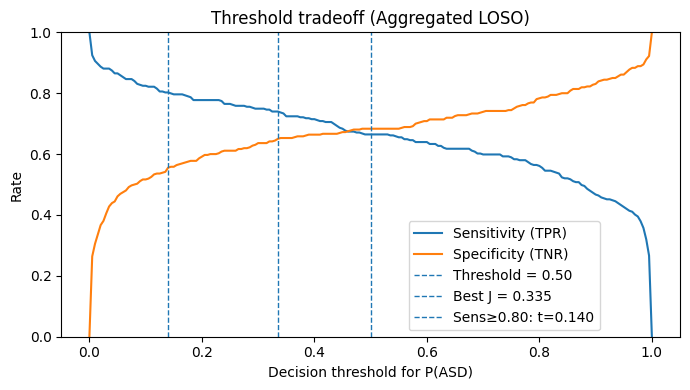

In [30]:
plt.figure(figsize=(7,4))
plt.plot(thr_df["threshold"], thr_df["sensitivity"], label="Sensitivity (TPR)")
plt.plot(thr_df["threshold"], thr_df["specificity"], label="Specificity (TNR)")
plt.axvline(0.5, linestyle="--", linewidth=1, label="Threshold = 0.50")

# Mark best-J threshold
plt.axvline(bestJ_row["threshold"], linestyle="--", linewidth=1, label=f"Best J = {bestJ_row['threshold']:.3f}")

# Mark sensitivity-optimized threshold if exists
if sensopt_row is not None:
    plt.axvline(sensopt_row["threshold"], linestyle="--", linewidth=1, label=f"Sens≥{target_sens:.2f}: t={sensopt_row['threshold']:.3f}")

plt.xlabel("Decision threshold for P(ASD)")
plt.ylabel("Rate")
plt.title("Threshold tradeoff (Aggregated LOSO)")
plt.ylim(0, 1)
plt.legend(loc="center left",
    bbox_to_anchor=(0.55, 0.2),   # (x, y) in axes fraction; increase x to move right
    frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "Threshold_tradeoff_LOSO"), dpi=200)
plt.show()

In [31]:
op_rows = []

# default
op_rows.append(["Default (0.50)",
                float(default_row["threshold"].iloc[0]),
                float(default_row["sensitivity"].iloc[0]),
                float(default_row["specificity"].iloc[0]),
                float(default_row["precision"].iloc[0]),
                float(default_row["f1"].iloc[0])])
# best J
op_rows.append(["Best Youden J", float(bestJ_row["threshold"]), float(bestJ_row["sensitivity"]), float(bestJ_row["specificity"]), float(bestJ_row["precision"]), float(bestJ_row["f1"])])

# sensitivity optimized
if sensopt_row is not None:
    op_rows.append([f"Sens≥{target_sens:.2f}", float(sensopt_row["threshold"]), float(sensopt_row["sensitivity"]), float(sensopt_row["specificity"]), float(sensopt_row["precision"]), float(sensopt_row["f1"])])

op_table = pd.DataFrame(op_rows, columns=["Operating point","Threshold","Sensitivity","Specificity","Precision","F1"])
op_table

,Operating point,Threshold,Sensitivity,Specificity,Precision,F1
0,Default (0.50),0.500,0.664577,0.683333,0.650307,0.657364
1,Best Youden J,0.335,0.739812,0.650000,0.651934,0.693098
2,Sens≥0.80,0.140,0.802508,0.555556,0.615385,0.696599


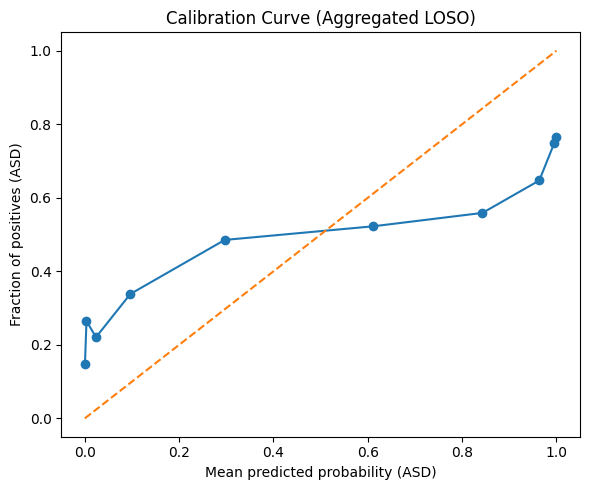

Brier score (lower is better): 0.2589


In [32]:
# --- Calibration curve (how trustworthy are predicted probabilities?) ---
prob_true, prob_pred = calibration_curve(
    y_true_all, y_pred_proba_all, n_bins=10, strategy="quantile"
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Mean predicted probability (ASD)")
plt.ylabel("Fraction of positives (ASD)")
plt.title("Calibration Curve (Aggregated LOSO)")
plt.tight_layout()
plt.show()

print(f"Brier score (lower is better): {brier_score_loss(y_true_all, y_pred_proba_all):.4f}")

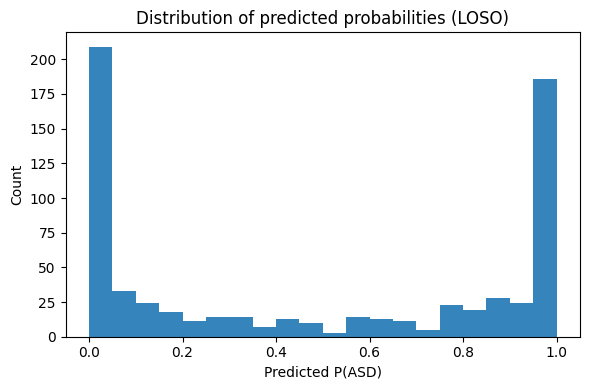

In [33]:
plt.figure(figsize=(6,4))
plt.hist(y_pred_proba_all, bins=20, alpha=0.9)
plt.xlabel("Predicted P(ASD)")
plt.ylabel("Count")
plt.title("Distribution of predicted probabilities (LOSO)")
plt.tight_layout()
plt.show()

In [34]:
summary_table = pd.DataFrame([
    ["Accuracy",          ci_acc[0],    ci_acc[1],    ci_acc[2]],
    ["Balanced Accuracy", ci_balacc[0], ci_balacc[1], ci_balacc[2]],
    ["ROC-AUC",           ci_auc[0],    ci_auc[1],    ci_auc[2]],
    ["Sensitivity (TPR)", ci_sens[0],   ci_sens[1],   ci_sens[2]],
    ["Specificity (TNR)", ci_spec[0],   ci_spec[1],   ci_spec[2]],
    ["Brier score",       ci_brier[0],  ci_brier[1],  ci_brier[2]],
], columns=["Metric", "Estimate", "CI_low", "CI_high"])

summary_table_fmt = summary_table.copy()
for c in ["Estimate", "CI_low", "CI_high"]:
    summary_table_fmt[c] = summary_table_fmt[c].map(lambda x: f"{x:.3f}")
summary_table_fmt

,Metric,Estimate,CI_low,CI_high
0,Accuracy,0.674,0.638,0.710
1,Balanced Accuracy,0.673,0.638,0.709
2,ROC-AUC,0.737,0.699,0.774
3,Sensitivity (TPR),0.664,0.615,0.717
4,Specificity (TNR),0.682,0.632,0.731
5,Brier score,0.259,0.232,0.287


### Interpretation

Coefficient matrix shape: (200, 200)


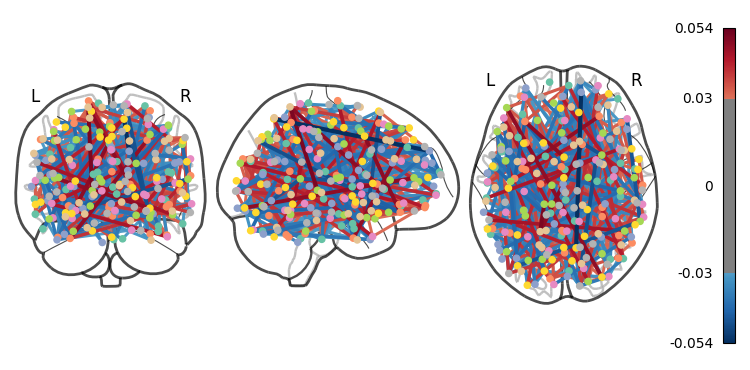

In [35]:
# Build connectivity matrix from model coefficients 
n_rois = len(coords)
coef_vector = mean_coefs  # logistic regression weights (length ~19900)
coef_matrix = np.zeros((n_rois, n_rois))

idx = 0
for i in range(n_rois):
    for j in range(i+1, n_rois):
        coef_matrix[i, j] = coef_vector[idx]
        coef_matrix[j, i] = coef_vector[idx]
        idx += 1

print("Coefficient matrix shape:", coef_matrix.shape)

# # Plot top connections 
# plotting.plot_connectome(coef_matrix, coords,
#                          edge_threshold="98%",
#                          # title="Top connections (LogReg weights, CC200)",
#                          node_size=20)
# plotting.show()

# Plot top connections
display = plotting.plot_connectome(
    coef_matrix, coords,
    edge_threshold="98%",
    node_size=20
)

out_path = os.path.join(DATA_DIR, "top_connections_connectome.png")
display.savefig(out_path, dpi=300)   # dpi=300 is good for posters

In [36]:
# atlas_200: 3D ROI label image (values 0..200)
# Example: atlas_200
# Make sure atlas_200 is Nifti1Image

yeo = datasets.fetch_atlas_yeo_2011(n_networks=7, thickness="thick")
yeo_path = yeo["maps"] if isinstance(yeo, dict) and "maps" in yeo else yeo.thick_7
yeo_img = nib.load(yeo_path)

# Resample Yeo to ROI atlas grid using nearest-neighbor (labels!)
yeo_rs = image.resample_to_img(
    yeo_img,
    atlas_200,
    interpolation="nearest",
    force_resample=True,   # silences upcoming default change
    copy_header=True       # adopts upcoming default header behavior
)

yeo_data = yeo_rs.get_fdata().astype(int)
roi_data = atlas_200.get_fdata().astype(int)

print("Resampled Yeo shape:", yeo_data.shape)
print("ROI atlas shape:", roi_data.shape)

[fetch_atlas_yeo_2011] Dataset found in C:\Users\A66702\nilearn_data\yeo_2011

Resampled Yeo shape: (47, 56, 46, 1)
ROI atlas shape: (47, 56, 46)


ROI->Network counts (0=unassigned): {0: 20, 1: 40, 2: 21, 3: 18, 4: 22, 5: 10, 6: 25, 7: 44}
Assigned networks:
  Visual (Vis): 40
  Somatomotor (SomMot): 21
  Dorsal Attention (DorsAttn): 18
  Ventral Attention (VentAttn): 22
  Limbic (Lim): 10
  Frontoparietal Control (FrontPar): 25
  Default Mode (DMN): 44
  Unassigned: 20
Total edges: 19900
Limbic-related edges: 1945
Non-limbic edges: 17955
Done in 336.7s
All edges                    | p=19900 | LOSO acc=0.700±0.151 | agg AUC=0.738
Only Limbic-related edges    | p= 1945 | LOSO acc=0.638±0.214 | agg AUC=0.702
All except Limbic edges      | p=17955 | LOSO acc=0.699±0.144 | agg AUC=0.729


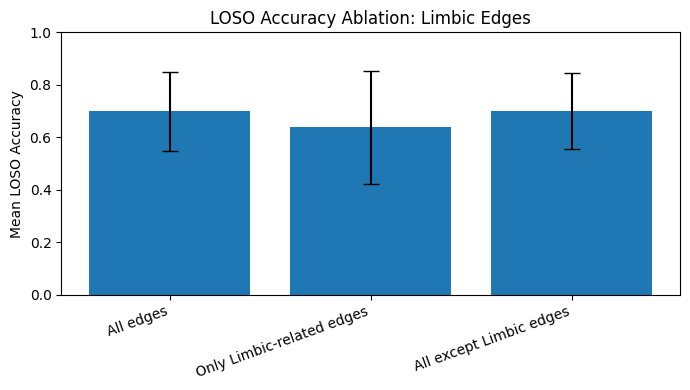

In [37]:
network_names = {
    1: "Visual (Vis)",
    2: "Somatomotor (SomMot)",
    3: "Dorsal Attention (DorsAttn)",
    4: "Ventral Attention (VentAttn)",
    5: "Limbic (Lim)",
    6: "Frontoparietal Control (FrontPar)",
    7: "Default Mode (DMN)"
}

roi_net = np.zeros(200, dtype=int)  # 0 = unassigned/other

roi_labels = np.unique(roi_data)
roi_labels = roi_labels[(roi_labels != 0) & (roi_labels <= 200)]
roi_labels = np.sort(roi_labels)

for lab in roi_labels:
    mask = (roi_data == lab)
    yeo_vals = yeo_data[mask]
    yeo_vals = yeo_vals[yeo_vals != 0]  # ignore background

    if yeo_vals.size == 0:
        roi_net[lab-1] = 0
    else:
        # majority overlap label
        roi_net[lab-1] = int(pd.Series(yeo_vals).value_counts().idxmax())

# summary
vals, cnts = np.unique(roi_net, return_counts=True)
print("ROI->Network counts (0=unassigned):", {int(v): int(c) for v, c in zip(vals, cnts)})

print("Assigned networks:")
for k in range(1, 8):
    print(f"  {network_names[k]:>8}: {(roi_net==k).sum()}")
print("  Unassigned:", (roi_net==0).sum())


# -----------------------------
# Ablation: Limbic edge subsets
# -----------------------------
# roi_net: length 200, values 1..7 (0 = unassigned)
# X: (n_subjects, 19900), upper-triangle edges

R = 200
iu = np.triu_indices(R, k=1)  # must match how X was built
roi_i, roi_j = iu[0], iu[1]   # 0-based ROI indices for each of the 19,900 edges

LIMBIC_ID = 5  # network_names dict: 5 = Limbic
limbic_edge_mask = (roi_net[roi_i] == LIMBIC_ID) | (roi_net[roi_j] == LIMBIC_ID)

print("Total edges:", limbic_edge_mask.size)
print("Limbic-related edges:", limbic_edge_mask.sum())
print("Non-limbic edges:", (~limbic_edge_mask).sum())

# Create 3 feature matrices
X_all = X
X_only_limbic = X[:, limbic_edge_mask]
X_no_limbic = X[:, ~limbic_edge_mask]

# Run LOSO for each condition
t0 = time.time()
res_all = run_loso_eval(X_all, y, groups, random_seed=RANDOM_SEED)
res_only = run_loso_eval(X_only_limbic, y, groups, random_seed=RANDOM_SEED)
res_nolimbic = run_loso_eval(X_no_limbic, y, groups, random_seed=RANDOM_SEED)
print(f"Done in {time.time()-t0:.1f}s")

# Summarize
ablation_summary = [
    ("All edges", X_all.shape[1], res_all["mean_fold_acc"], res_all["std_fold_acc"], res_all["agg_auc"]),
    ("Only Limbic-related edges", X_only_limbic.shape[1], res_only["mean_fold_acc"], res_only["std_fold_acc"], res_only["agg_auc"]),
    ("All except Limbic edges", X_no_limbic.shape[1], res_nolimbic["mean_fold_acc"], res_nolimbic["std_fold_acc"], res_nolimbic["agg_auc"]),
]

for name, p, acc, sd, auc in ablation_summary:
    print(f"{name:28s} | p={p:5d} | LOSO acc={acc:.3f}±{sd:.3f} | agg AUC={auc:.3f}")

# Bar chart: mean LOSO accuracy with fold-std error bars
labels = [x[0] for x in ablation_summary]
means  = np.array([x[2] for x in ablation_summary], dtype=float)
errs   = np.array([x[3] for x in ablation_summary], dtype=float)

plt.figure(figsize=(7, 4))
plt.bar(labels, means, yerr=errs, capsize=6)
plt.ylabel("Mean LOSO Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.title("LOSO Accuracy Ablation: Limbic Edges")
plt.tight_layout()
plt.show()

Yeo-7 atlas is a cortical network atlas, and cc-200 ROI parcellation includes regions that don’t cleanly overlap those cortical network labels. 20 ROIs end up as “Other/Unassigned” because they’re non-cortical or poorly overlapping cortex. So better to label them as “Other” than to force them into the wrong cortical network.

In [38]:
valid = roi_net > 0
idx_valid = np.where(valid)[0]
print("ROIs mapped to Yeo networks:", len(idx_valid), "/ 200")

# coef_matrix should be 200x200 symmetric weight matrix
coef_valid = coef_matrix[np.ix_(idx_valid, idx_valid)]
net_valid = roi_net[idx_valid]

valid_nets = [1,2,3,4,5,6,7]
net_labels = [network_names[k] for k in valid_nets]
K = len(valid_nets)

net_importance = np.full((K, K), np.nan, dtype=float)
net_counts = np.zeros((K, K), dtype=int)

for a_idx, a in enumerate(valid_nets):
    ia = np.where(net_valid == a)[0]
    for b_idx, b in enumerate(valid_nets):
        ib = np.where(net_valid == b)[0]
        if len(ia) == 0 or len(ib) == 0:
            continue

        block = coef_valid[np.ix_(ia, ib)]

        if a == b:
            tri = np.triu_indices(len(ia), k=1)
            vals = np.abs(block[tri])
            net_counts[a_idx, b_idx] = len(vals)
        else:
            vals = np.abs(block).ravel()
            net_counts[a_idx, b_idx] = vals.size

        net_importance[a_idx, b_idx] = np.mean(vals) if vals.size else np.nan

print("Computed net_importance:", net_importance.shape)

ROIs mapped to Yeo networks: 180 / 200
Computed net_importance: (7, 7)


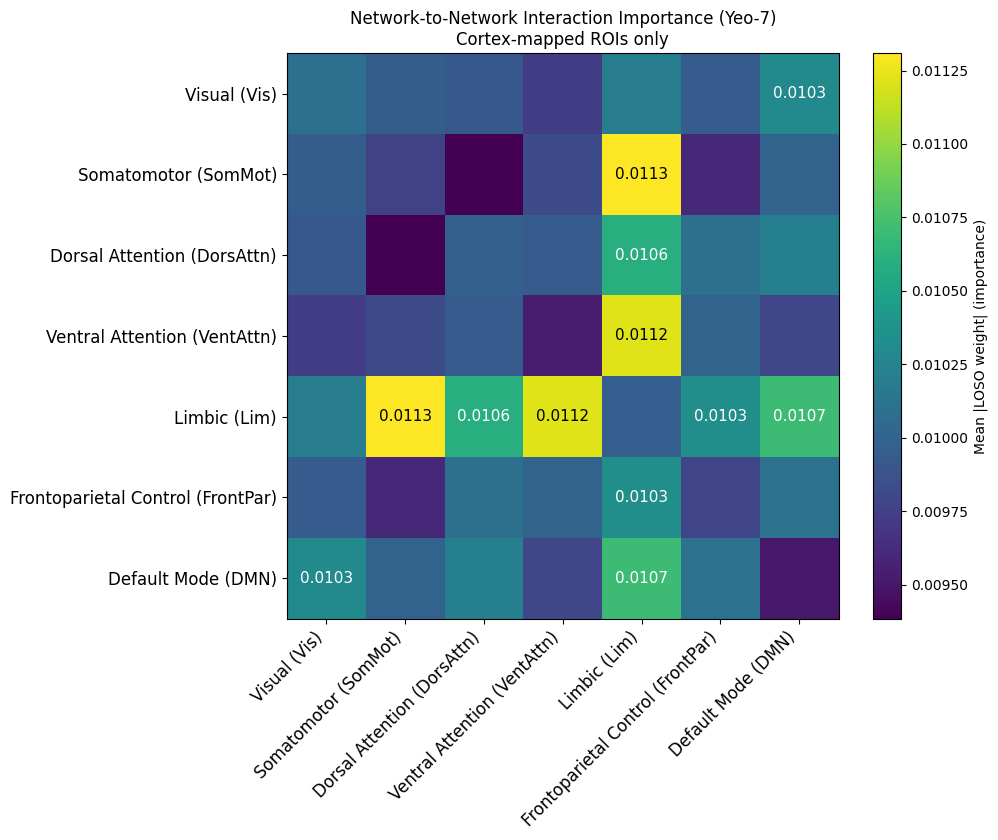

Top 10 network pairs by mean |weight|:
Somatomotor (SomMot)–Limbic (Lim): 0.011309 (edges=210)
Ventral Attention (VentAttn)–Limbic (Lim): 0.011217 (edges=220)
Limbic (Lim)–Default Mode (DMN): 0.010702 (edges=440)
Dorsal Attention (DorsAttn)–Limbic (Lim): 0.010594 (edges=180)
Limbic (Lim)–Frontoparietal Control (FrontPar): 0.010333 (edges=250)
Visual (Vis)–Default Mode (DMN): 0.010301 (edges=1760)
Dorsal Attention (DorsAttn)–Default Mode (DMN): 0.010219 (edges=792)
Visual (Vis)–Limbic (Lim): 0.010200 (edges=400)
Frontoparietal Control (FrontPar)–Default Mode (DMN): 0.010103 (edges=1100)
Dorsal Attention (DorsAttn)–Frontoparietal Control (FrontPar): 0.010092 (edges=450)


In [39]:
plt.figure(figsize=(10,8.5))
plt.imshow(net_importance, aspect="auto")
plt.colorbar(label="Mean |LOSO weight| (importance)")
plt.xticks(range(K), net_labels, rotation=45, ha="right", fontsize=12)
plt.yticks(range(K), net_labels, fontsize=12)
plt.title("Network-to-Network Interaction Importance (Yeo-7)\nCortex-mapped ROIs only")

thr = 0.0103
for i in range(K):
    for j in range(K):
        val = net_importance[i, j]
        if np.isfinite(val) and val > thr:
            txt_color = "black" if val > (thr + 0.0007) else "white"
            plt.text(j, i, f"{val:.4f}", ha="center", va="center",
                     fontsize=11, color=txt_color)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "network_to_network_interaction_importance.png"), dpi=200)
plt.show()

pairs = []
for i in range(K):
    for j in range(i, K):
        imp = net_importance[i, j]
        if np.isfinite(imp):
            pairs.append((net_labels[i], net_labels[j], float(imp), int(net_counts[i, j])))

pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

print("Top 10 network pairs by mean |weight|:")
for a, b, imp, n_edges in pairs_sorted[:10]:
    print(f"{a}–{b}: {imp:.6f} (edges={n_edges})")

In [40]:
R = 200
iu = np.triu_indices(R, k=1)

# cortex-mapped ROIs (Yeo label 1..7); unassigned (0) excluded
idx_valid = np.where(roi_net > 0)[0]          # indices in [0..199]
net_valid = roi_net[idx_valid]                # corresponding network label per ROI
n_folds = coefs_all.shape[0]

print("Mapped ROIs:", len(idx_valid), "/ 200")
print("Folds:", n_folds, "Features:", coefs_all.shape[1])

network_names = {
    1: "Visual",
    2: "Somatomotor",
    3: "Dorsal Attention",
    4: "Ventral Attention",
    5: "Limbic",
    6: "Frontoparietal Control",
    7: "Default Mode"
}
valid_nets = [1,2,3,4,5,6,7]
net_labels = [network_names[k] for k in valid_nets]
K = len(valid_nets)

def coefvec_to_mat(coef_vec, R=200):
    """Upper-triangle vector -> symmetric RxR matrix (diag=0)."""
    M = np.zeros((R, R), dtype=float)
    M[iu] = coef_vec
    M = M + M.T
    return M

def block_importance_from_mat(M, idx_valid, net_valid, valid_nets):
    """
    Return KxK matrix where each cell is mean absolute weight for edges
    connecting ROIs in two networks (cortex-mapped ROIs only).
    """
    Mv = M[np.ix_(idx_valid, idx_valid)]
    out = np.full((K, K), np.nan, dtype=float)

    for a_idx, a in enumerate(valid_nets):
        ia = np.where(net_valid == a)[0]
        for b_idx, b in enumerate(valid_nets):
            ib = np.where(net_valid == b)[0]
            if len(ia) == 0 or len(ib) == 0:
                continue

            block = Mv[np.ix_(ia, ib)]

            # avoid double-counting within-network edges
            if a == b:
                tri = np.triu_indices(len(ia), k=1)
                vals = np.abs(block[tri])
            else:
                vals = np.abs(block).ravel()

            out[a_idx, b_idx] = np.mean(vals) if vals.size else np.nan

    return out

blocks = np.zeros((n_folds, K, K), dtype=float)

for f in range(n_folds):
    M = coefvec_to_mat(coefs_all[f], R=R)
    blocks[f] = block_importance_from_mat(M, idx_valid, net_valid, valid_nets)

print("blocks shape:", blocks.shape)  # (folds, 7, 7)

Mapped ROIs: 180 / 200
Folds: 24 Features: 19900
blocks shape: (24, 7, 7)


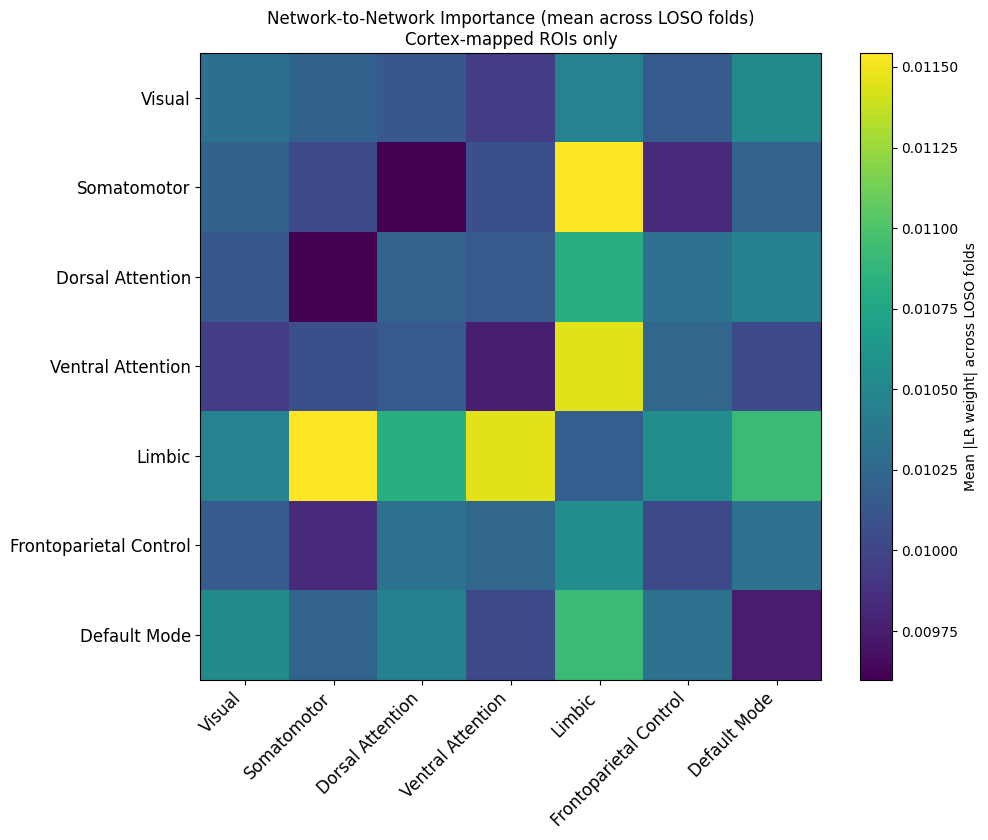

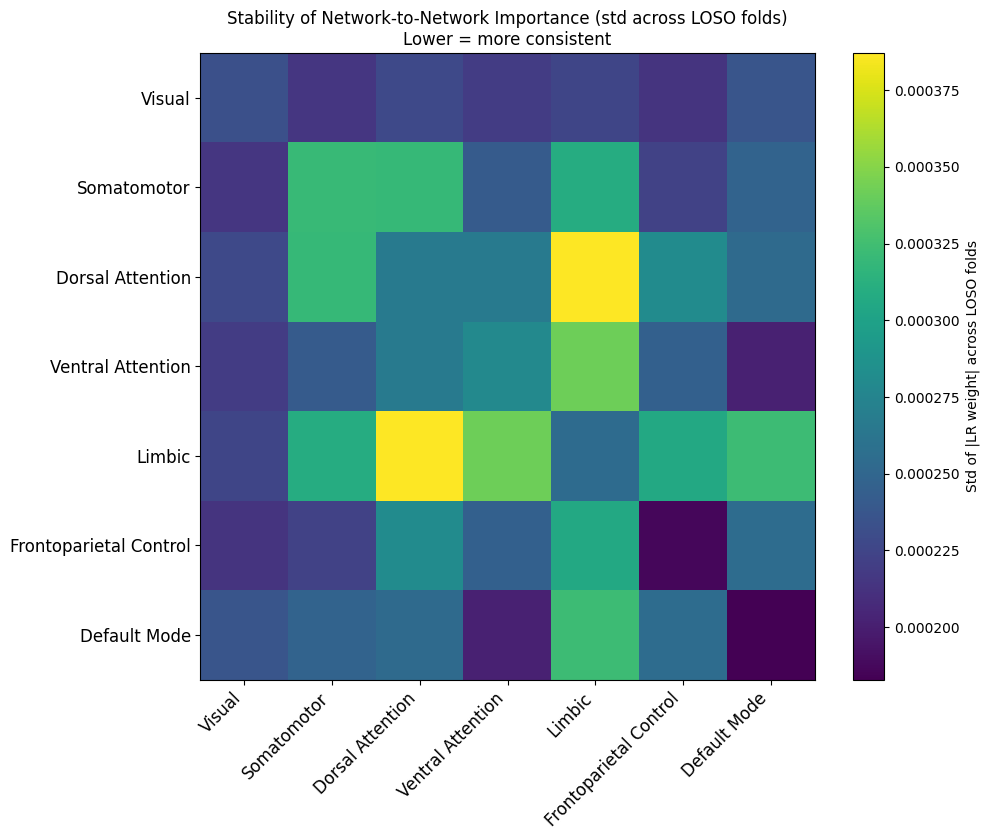

In [41]:
block_mean = np.nanmean(blocks, axis=0)
block_std  = np.nanstd(blocks, axis=0)

# 1) Mean heatmap
plt.figure(figsize=(10,8.5))
plt.imshow(block_mean, aspect="auto")
plt.colorbar(label="Mean |LR weight| across LOSO folds")
plt.xticks(range(K), net_labels, rotation=45, ha="right", fontsize=12)
plt.yticks(range(K), net_labels, fontsize=12)
plt.title("Network-to-Network Importance (mean across LOSO folds)\nCortex-mapped ROIs only")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "network_block_mean.png"), dpi=200, bbox_inches="tight")
plt.show()

# 2) Std heatmap
plt.figure(figsize=(10,8.5))
plt.imshow(block_std, aspect="auto")
plt.colorbar(label="Std of |LR weight| across LOSO folds")
plt.xticks(range(K), net_labels, rotation=45, ha="right", fontsize=12)
plt.yticks(range(K), net_labels, fontsize=12)
plt.title("Stability of Network-to-Network Importance (std across LOSO folds)\nLower = more consistent")
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "network_block_std.png"), dpi=200, bbox_inches="tight")
plt.show()

In [42]:
# Permutation Test
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def run_one_permutation(seed):
    rng = np.random.RandomState(seed)
    y_perm = rng.permutation(y)
    fold_accs_perm = []
    for train_idx, test_idx in logo.split(X_scaled, y_perm, groups):
        X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
        y_tr_perm, y_te_perm = y_perm[train_idx], y_perm[test_idx]
        clf = LogisticRegression(solver='lbfgs', max_iter=1000, n_jobs=-1)
        clf.fit(X_tr, y_tr_perm)
        yhat = clf.predict(X_te)
        fold_accs_perm.append(accuracy_score(y_te_perm, yhat))
    return np.mean(fold_accs_perm)

N_PERMS = 1000   
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
start_time = time.time()

perm_accs = Parallel(n_jobs=-1)(
    delayed(run_one_permutation)(RANDOM_SEED+i) for i in range(N_PERMS)
)
perm_accs = np.array(perm_accs)

p_value = (np.sum(perm_accs >= obs_acc) + 1) / (N_PERMS + 1)
print(f"Permutation test p-value = {p_value:.4f}")
print(f"Run time: {time.time()-start_time:.1f}s")

mean_null = perm_accs.mean()
std_null = perm_accs.std()
perc_95 = np.percentile(perm_accs, 95)
perc_99 = np.percentile(perm_accs, 99)

print(f"Null mean = {mean_null:.3f}, std = {std_null:.3f}")
print(f"95th percentile = {perc_95:.3f}, 99th percentile = {perc_99:.3f}")

z_score = (obs_acc - mean_null) / std_null
print(f"Observed z-score vs null = {z_score:.2f}")

results_df = pd.DataFrame({
    "obs_acc": [obs_acc],
    "p_value": [p_value],
    "null_mean": [mean_null],
    "null_std": [std_null],
    "z_score": [z_score],
    "perc_95": [perc_95],
    "perc_99": [perc_99]
})
results_df.to_csv(os.path.join(DATA_DIR, "permutation_summary.csv"), index=False)

Permutation test p-value = 0.0010
Run time: 31420.8s
Null mean = 0.493, std = 0.045
95th percentile = 0.566, 99th percentile = 0.592
Observed z-score vs null = 4.57


Saved permutation histogram to permutation_histogram.png
All done.


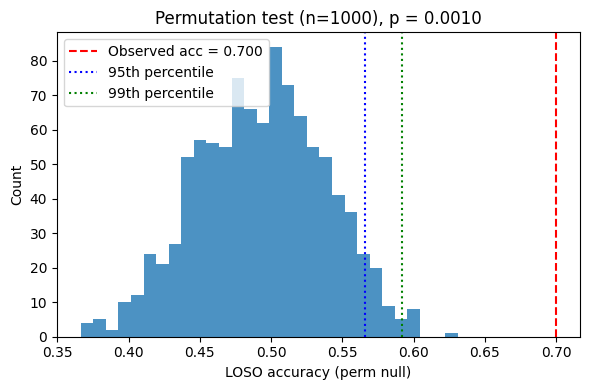

In [43]:
# Plot permutation histogram with observed accuracy 
plt.figure(figsize=(6,4))
plt.hist(perm_accs, bins=30, alpha=0.8)
plt.axvline(obs_acc, color='red', linestyle='--', label=f"Observed acc = {obs_acc:.3f}")
plt.axvline(perc_95, color="blue", linestyle=":", label="95th percentile")
plt.axvline(perc_99, color="green", linestyle=":", label="99th percentile")
plt.xlabel("LOSO accuracy (perm null)")
plt.ylabel("Count")
plt.title(f"Permutation test (n={N_PERMS}), p = {p_value:.4f}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "permutation_histogram.png"), dpi=200)
print("Saved permutation histogram to permutation_histogram.png")

# Save numerical outputs for later reporting 
np.save(os.path.join(DATA_DIR, "X_fc_cc200.npy"), X)
np.save(os.path.join(DATA_DIR, "y_fc_cc200.npy"), y)
np.save(os.path.join(DATA_DIR, "groups_fc_cc200.npy"), groups)
np.save(os.path.join(DATA_DIR, "perm_accs.npy"), perm_accs)

print("All done.")